In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path ="/content/drive/MyDrive/MLMiniProject/archive"
print("Path to dataset files:", path)

Path to dataset files: /content/drive/MyDrive/MLMiniProject/archive


In [ ]:
!nvidia-smi

Sun Apr  5 08:17:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os

print("Main folder contents:", os.listdir(path))



Main folder contents: ['deliveries.csv', 'matches.csv', 'test.csv', 'train.csv', 'val.csv', 'test', 'val', 'train']


In [ ]:
import pandas as pd
df=pd.read_csv(os.path.join(path, 'test.csv'))
print(df.head())

         clip_name                        clip_path  label
0  v_Swing_g21_c02  /test/Swing/v_Swing_g21_c02.avi  Swing
1  v_Swing_g21_c06  /test/Swing/v_Swing_g21_c06.avi  Swing
2  v_Swing_g20_c05  /test/Swing/v_Swing_g20_c05.avi  Swing
3  v_Swing_g04_c03  /test/Swing/v_Swing_g04_c03.avi  Swing
4  v_Swing_g19_c03  /test/Swing/v_Swing_g19_c03.avi  Swing


In [ ]:

df=pd.read_csv(os.path.join(path, 'val.csv'))
print(df.head())

         clip_name                       clip_path  label
0  v_Swing_g22_c05  /val/Swing/v_Swing_g22_c05.avi  Swing
1  v_Swing_g25_c02  /val/Swing/v_Swing_g25_c02.avi  Swing
2  v_Swing_g06_c07  /val/Swing/v_Swing_g06_c07.avi  Swing
3  v_Swing_g03_c02  /val/Swing/v_Swing_g03_c02.avi  Swing
4  v_Swing_g02_c05  /val/Swing/v_Swing_g02_c05.avi  Swing


First 5 rows of metadata:
         clip_name                         clip_path  label
0  v_Swing_g05_c02  /train/Swing/v_Swing_g05_c02.avi  Swing
1  v_Swing_g21_c03  /train/Swing/v_Swing_g21_c03.avi  Swing
2  v_Swing_g07_c01  /train/Swing/v_Swing_g07_c01.avi  Swing
3  v_Swing_g24_c04  /train/Swing/v_Swing_g24_c04.avi  Swing
4  v_Swing_g20_c03  /train/Swing/v_Swing_g20_c03.avi  Swing


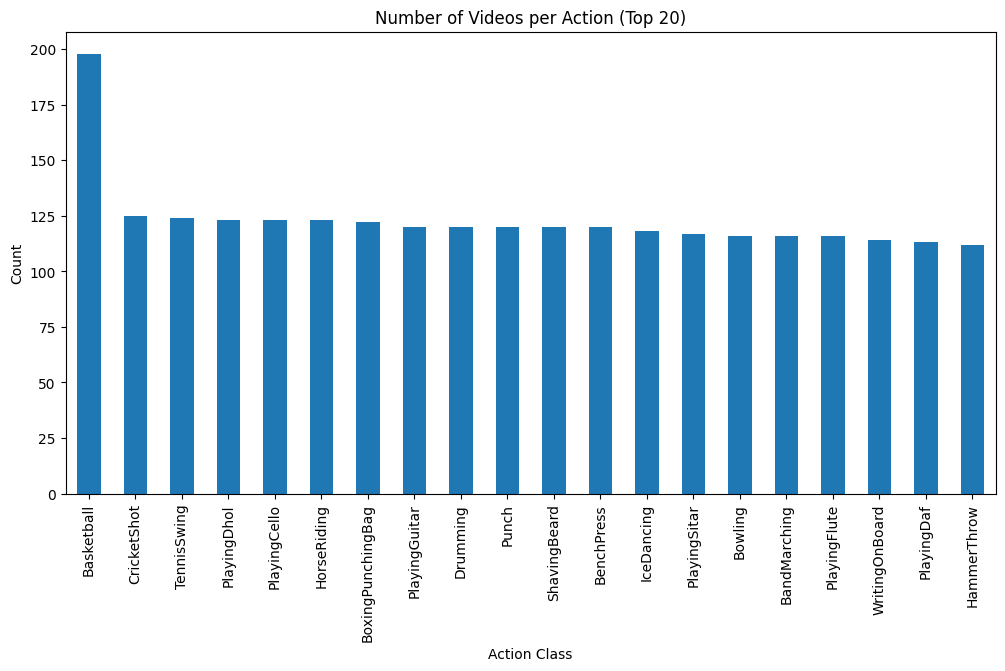

Total classes: 101
Most common action: Basketball (198 videos)
Rarest action: BreastStroke (75 videos)


In [ ]:

import matplotlib.pyplot as plt
import os

df_train = pd.read_csv(os.path.join(path, 'train.csv'))

print("First 5 rows of metadata:")
print(df_train.head())

label_counts = df_train['label'].value_counts()

plt.figure(figsize=(12, 6))
label_counts[:20].plot(kind='bar')
plt.title("Number of Videos per Action (Top 20)")
plt.xlabel("Action Class")
plt.ylabel("Count")
plt.show()

print(f"Total classes: {len(label_counts)}")
print(f"Most common action: {label_counts.idxmax()} ({label_counts.max()} videos)")
print(f"Rarest action: {label_counts.idxmin()} ({label_counts.min()} videos)")

In [ ]:
label_counts = df_train['label'].value_counts()
print(label_counts)


label
Basketball       198
CricketShot      125
TennisSwing      124
PlayingDhol      123
PlayingCello     123
                ... 
BreastStroke      75
PullUps           75
TaiChi            75
PlayingViolin     75
Skijet            75
Name: count, Length: 101, dtype: int64


In [ ]:
ranked_classes = label_counts.reset_index()
ranked_classes.columns = ['Action Class', 'Number of Videos']
ranked_classes['Rank'] = ranked_classes.index + 1
ranked_classes = ranked_classes[['Rank', 'Action Class', 'Number of Videos']]
print(ranked_classes)


     Rank   Action Class  Number of Videos
0       1     Basketball               198
1       2    CricketShot               125
2       3    TennisSwing               124
3       4    PlayingDhol               123
4       5   PlayingCello               123
..    ...            ...               ...
96     97   BreastStroke                75
97     98        PullUps                75
98     99         TaiChi                75
99    100  PlayingViolin                75
100   101         Skijet                75

[101 rows x 3 columns]


In [ ]:
ranked_classes.to_csv("UCF101_Class_Ranking.csv", index=False)
print("Saved as UCF101_Class_Ranking.csv")


Saved as UCF101_Class_Ranking.csv


In [ ]:
label_counts = df_train['label'].value_counts()
top_20 = label_counts.head(20)
print(top_20)


label
Basketball           198
CricketShot          125
TennisSwing          124
PlayingDhol          123
PlayingCello         123
HorseRiding          123
BoxingPunchingBag    122
PlayingGuitar        120
Drumming             120
Punch                120
ShavingBeard         120
BenchPress           120
IceDancing           118
PlayingSitar         117
Bowling              116
BandMarching         116
PlayingFlute         116
WritingOnBoard       114
PlayingDaf           113
HammerThrow          112
Name: count, dtype: int64


In [ ]:
selected_classes = [
    "Basketball",
    "CricketShot",
    "TennisSwing",
    "BoxingPunchingBag",
    "Punch",
    "BenchPress",
    "Bowling",
    "HammerThrow"
]


In [ ]:
filtered_df = df_train[df_train['label'].isin(selected_classes)]

small_df = (
    filtered_df
    .groupby('label')
    .head(5)
    .reset_index(drop=True)
)

print(small_df['label'].value_counts())


label
BenchPress           5
TennisSwing          5
HammerThrow          5
BoxingPunchingBag    5
Punch                5
Bowling              5
Basketball           5
CricketShot          5
Name: count, dtype: int64


In [ ]:
print(small_df.head(10))

               clip_name                                     clip_path  \
0   v_BenchPress_g14_c03    /train/BenchPress/v_BenchPress_g14_c03.avi   
1   v_BenchPress_g05_c06    /train/BenchPress/v_BenchPress_g05_c06.avi   
2   v_BenchPress_g21_c03    /train/BenchPress/v_BenchPress_g21_c03.avi   
3   v_BenchPress_g23_c05    /train/BenchPress/v_BenchPress_g23_c05.avi   
4   v_BenchPress_g25_c01    /train/BenchPress/v_BenchPress_g25_c01.avi   
5  v_TennisSwing_g04_c03  /train/TennisSwing/v_TennisSwing_g04_c03.avi   
6  v_TennisSwing_g16_c05  /train/TennisSwing/v_TennisSwing_g16_c05.avi   
7  v_TennisSwing_g10_c05  /train/TennisSwing/v_TennisSwing_g10_c05.avi   
8  v_TennisSwing_g09_c03  /train/TennisSwing/v_TennisSwing_g09_c03.avi   
9  v_TennisSwing_g11_c04  /train/TennisSwing/v_TennisSwing_g11_c04.avi   

         label  
0   BenchPress  
1   BenchPress  
2   BenchPress  
3   BenchPress  
4   BenchPress  
5  TennisSwing  
6  TennisSwing  
7  TennisSwing  
8  TennisSwing  
9  TennisSwing 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(y_true, y_pred, class_names, model_name="Model"):
    """Plots a heatmap of the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.ylabel('Actual Action (Ground Truth)', fontweight='bold')
    plt.xlabel('Predicted Action', fontweight='bold')
    plt.title(f'Confusion Matrix: {model_name}', fontsize=14, fontweight='bold')
    plt.show()

# Extract your exact class names from your dataset creation step
# Update this list to match the 8 classes you selected for your mini_dataset
CLASSES = ['Class1', 'Class2', 'Class3', 'Class4', 'Class5', 'Class6', 'Class7', 'Class8']

In [ ]:
import os
import cv2
import numpy as np

output_dir = "/content/drive/MyDrive/MLMiniProject/mini_dataset"
os.makedirs(output_dir, exist_ok=True)


In [ ]:
def extract_frames(video_path, save_folder, num_frames=16):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < num_frames:
        print("Skipping short video:", video_path)
        return

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()

        if not ret:
            continue

        frame = cv2.resize(frame, (224, 224))

        video_name = os.path.basename(video_path).split(".")[0]
        save_path = os.path.join(save_folder, f"{video_name}_frame_{i}.jpg")

        cv2.imwrite(save_path, frame)

    cap.release()


In [ ]:
for index, row in small_df.iterrows():

    label = row['label']

    relative_path = row['clip_path'].lstrip("/")

    video_path = os.path.join(path, relative_path)

    class_folder = os.path.join(output_dir, label)
    os.makedirs(class_folder, exist_ok=True)

    print("Processing:", video_path)

    extract_frames(video_path, class_folder)


Processing: /content/drive/MyDrive/MLMiniProject/archive/train/BenchPress/v_BenchPress_g14_c03.avi
Processing: /content/drive/MyDrive/MLMiniProject/archive/train/BenchPress/v_BenchPress_g05_c06.avi
Processing: /content/drive/MyDrive/MLMiniProject/archive/train/BenchPress/v_BenchPress_g21_c03.avi
Processing: /content/drive/MyDrive/MLMiniProject/archive/train/BenchPress/v_BenchPress_g23_c05.avi
Processing: /content/drive/MyDrive/MLMiniProject/archive/train/BenchPress/v_BenchPress_g25_c01.avi
Processing: /content/drive/MyDrive/MLMiniProject/archive/train/TennisSwing/v_TennisSwing_g04_c03.avi
Processing: /content/drive/MyDrive/MLMiniProject/archive/train/TennisSwing/v_TennisSwing_g16_c05.avi
Processing: /content/drive/MyDrive/MLMiniProject/archive/train/TennisSwing/v_TennisSwing_g10_c05.avi
Processing: /content/drive/MyDrive/MLMiniProject/archive/train/TennisSwing/v_TennisSwing_g09_c03.avi
Processing: /content/drive/MyDrive/MLMiniProject/archive/train/TennisSwing/v_TennisSwing_g11_c04.avi


In [ ]:
for folder in os.listdir(output_dir):
    print(folder, len(os.listdir(os.path.join(output_dir, folder))))


BenchPress 80
TennisSwing 80
HammerThrow 80
BoxingPunchingBag 80
Punch 80
Bowling 80
Basketball 79
CricketShot 80


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/MLMiniProject/mini_dataset/BenchPress"))


['v_BenchPress_g14_c03_frame_0.jpg', 'v_BenchPress_g14_c03_frame_5.jpg', 'v_BenchPress_g14_c03_frame_1.jpg', 'v_BenchPress_g14_c03_frame_3.jpg', 'v_BenchPress_g14_c03_frame_6.jpg', 'v_BenchPress_g14_c03_frame_7.jpg', 'v_BenchPress_g14_c03_frame_2.jpg', 'v_BenchPress_g14_c03_frame_9.jpg', 'v_BenchPress_g14_c03_frame_4.jpg', 'v_BenchPress_g14_c03_frame_8.jpg', 'v_BenchPress_g14_c03_frame_10.jpg', 'v_BenchPress_g14_c03_frame_11.jpg', 'v_BenchPress_g14_c03_frame_12.jpg', 'v_BenchPress_g14_c03_frame_13.jpg', 'v_BenchPress_g14_c03_frame_14.jpg', 'v_BenchPress_g05_c06_frame_0.jpg', 'v_BenchPress_g05_c06_frame_1.jpg', 'v_BenchPress_g14_c03_frame_15.jpg', 'v_BenchPress_g05_c06_frame_2.jpg', 'v_BenchPress_g05_c06_frame_3.jpg', 'v_BenchPress_g05_c06_frame_4.jpg', 'v_BenchPress_g05_c06_frame_5.jpg', 'v_BenchPress_g05_c06_frame_6.jpg', 'v_BenchPress_g05_c06_frame_7.jpg', 'v_BenchPress_g05_c06_frame_8.jpg', 'v_BenchPress_g05_c06_frame_10.jpg', 'v_BenchPress_g05_c06_frame_9.jpg', 'v_BenchPress_g05_c0

In [ ]:
import os
import cv2
import numpy as np

folder = "/content/drive/MyDrive/MLMiniProject/mini_dataset/BenchPress"

first_image = os.listdir(folder)[0]

sample_img_path = os.path.join(folder, first_image)

img = cv2.imread(sample_img_path)

print("Image loaded successfully:", img is not None)

low_light = (img * 0.4).clip(0,255).astype(np.uint8)

cv2.imwrite("low_light_example.jpg", low_light)


Image loaded successfully: True


True

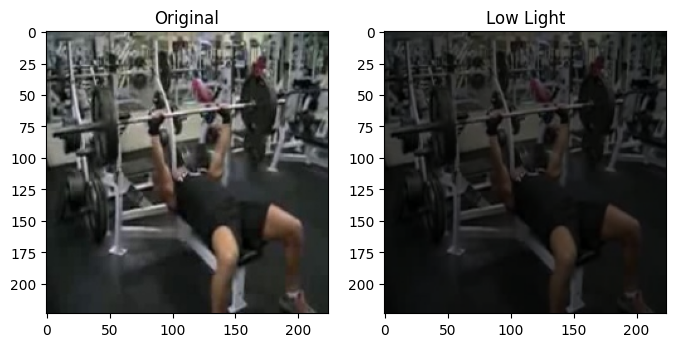

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(low_light, cv2.COLOR_BGR2RGB))
plt.title("Low Light")

plt.show()


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm


In [ ]:
input_dir = "/content/drive/MyDrive/MLMiniProject/mini_dataset"
output_dir = "/content/drive/MyDrive/MLMiniProject/processed_dataset"

variants = ["normal", "low_light", "motion_blur", "occlusion"]

for v in variants:
    os.makedirs(os.path.join(output_dir, v), exist_ok=True)


In [ ]:
for action in os.listdir(input_dir):
    src_folder = os.path.join(input_dir, action)
    dst_folder = os.path.join(output_dir, "normal", action)
    os.makedirs(dst_folder, exist_ok=True)

    for img_name in os.listdir(src_folder):
        img = cv2.imread(os.path.join(src_folder, img_name))
        cv2.imwrite(os.path.join(dst_folder, img_name), img)


In [ ]:
for action in os.listdir(input_dir):
    src_folder = os.path.join(input_dir, action)
    dst_folder = os.path.join(output_dir, "low_light", action)
    os.makedirs(dst_folder, exist_ok=True)

    for img_name in os.listdir(src_folder):
        img = cv2.imread(os.path.join(src_folder, img_name))
        low_light = (img * 0.4).clip(0,255).astype(np.uint8)
        cv2.imwrite(os.path.join(dst_folder, img_name), low_light)


In [ ]:
def motion_blur(img, kernel_size=15):
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel /= kernel_size
    return cv2.filter2D(img, -1, kernel)

for action in os.listdir(input_dir):
    src_folder = os.path.join(input_dir, action)
    dst_folder = os.path.join(output_dir, "motion_blur", action)
    os.makedirs(dst_folder, exist_ok=True)

    for img_name in os.listdir(src_folder):
        img = cv2.imread(os.path.join(src_folder, img_name))
        blurred = motion_blur(img)
        cv2.imwrite(os.path.join(dst_folder, img_name), blurred)


In [ ]:
def apply_occlusion(img):
    h, w, _ = img.shape
    x1 = np.random.randint(0, w//2)
    y1 = np.random.randint(0, h//2)
    x2 = x1 + np.random.randint(w//4, w//2)
    y2 = y1 + np.random.randint(h//4, h//2)
    img[y1:y2, x1:x2] = 0
    return img

for action in os.listdir(input_dir):
    src_folder = os.path.join(input_dir, action)
    dst_folder = os.path.join(output_dir, "occlusion", action)
    os.makedirs(dst_folder, exist_ok=True)

    for img_name in os.listdir(src_folder):
        img = cv2.imread(os.path.join(src_folder, img_name))
        occluded = apply_occlusion(img)
        cv2.imwrite(os.path.join(dst_folder, img_name), occluded)


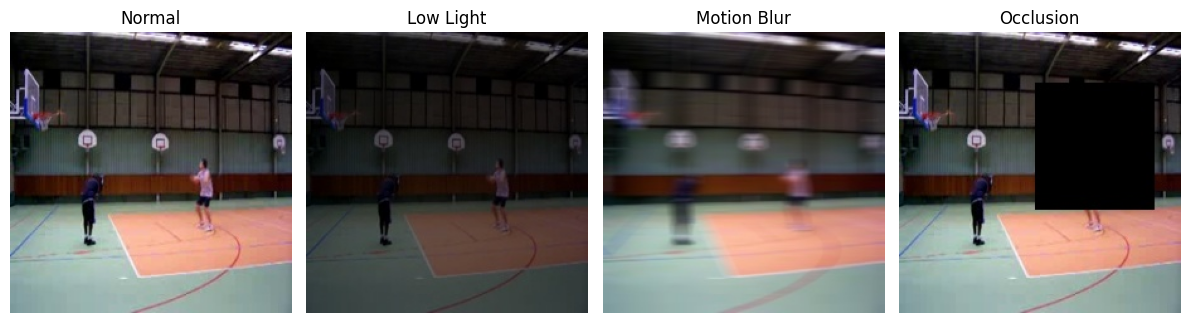

In [ ]:
action = "Basketball"
img_name = os.listdir(os.path.join("/content/drive/MyDrive/MLMiniProject/processed_dataset", "normal", action))[0]

paths = {
    "Normal": os.path.join("/content/drive/MyDrive/MLMiniProject/processed_dataset", "normal", action, img_name),
    "Low Light": os.path.join("/content/drive/MyDrive/MLMiniProject/processed_dataset", "low_light", action, img_name),
    "Motion Blur": os.path.join("/content/drive/MyDrive/MLMiniProject/processed_dataset", "motion_blur", action, img_name),
    "Occlusion": os.path.join("/content/drive/MyDrive/MLMiniProject/processed_dataset", "occlusion", action, img_name)
}

plt.figure(figsize=(12,4))

for i, (title, path) in enumerate(paths.items()):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!pip install transformers accelerate

import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

class UCF101MiniDataset(Dataset):
    def __init__(self, root_dir, processor, num_frames=16):
        self.root_dir = root_dir
        self.processor = processor
        self.num_frames = num_frames
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.video_paths = []
        self.labels = []

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            frames = sorted(os.listdir(cls_dir))
            video_names = set([f.split('_frame_')[0] for f in frames])

            for vid in video_names:
                vid_frames = [os.path.join(cls_dir, f"{vid}_frame_{i}.jpg") for i in range(num_frames)]
                if all(os.path.exists(f) for f in vid_frames):
                    self.video_paths.append(vid_frames)
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        frame_paths = self.video_paths[idx]
        label = self.labels[idx]
        video = []

        for path in frame_paths:
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            video.append(img)

        inputs = self.processor(list(video), return_tensors="pt")

        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'label': torch.tensor(label)
        }

model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)

dataset_path = "/content/drive/MyDrive/MLMiniProject/mini_dataset"
dataset = UCF101MiniDataset(root_dir=dataset_path, processor=processor)

dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

id2label = {i: cls for cls, i in dataset.class_to_idx.items()}
label2id = dataset.class_to_idx

model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    num_labels=len(dataset.classes),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

batch = next(iter(dataloader))
print(batch['pixel_values'].shape)
print(batch['label'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base-finetuned-kinetics
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400, 768]) vs model:torch.Size([8, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400]) vs model:torch.Size([8])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


torch.Size([2, 16, 3, 224, 224])
tensor([1, 1])


In [ ]:
!pip install evaluate scikit-learn

import numpy as np
import evaluate
import torch
from transformers import TrainingArguments, Trainer

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

args = TrainingArguments(
    output_dir="/content/drive/MyDrive/MLMiniProject/videomae-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    remove_unused_columns=False
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

trainer.train()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.750185,0.375000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
from transformers import TrainingArguments

# 1. Re-define the minimum required arguments just for evaluation
training_args = TrainingArguments(
    output_dir="./temp_eval",     # A temporary folder, it won't actually save any models
    per_device_eval_batch_size=2, # Keeps memory usage low to prevent Colab from crashing
    remove_unused_columns=False   # Important for VideoMAE to keep video frames intact
)

# 2. Now run the trainer setup
eval_trainer = Trainer(
    model=saved_model,
    args=training_args,
    eval_dataset=val_dataset,
    data_collator=collate_fn,  # If you get a NameError here too, let me know!
)

In [ ]:
!pip install torch torchvision

In [ ]:
#cnn starting

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import os
import json

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from collections import defaultdict

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

base_path = "/content/MLMiniProject"
cnn_folder = os.path.join(base_path, "cnn-model")
os.makedirs(cnn_folder, exist_ok=True)

dataset_path = "/content/drive/MyDrive/MLMiniProject/processed_dataset/normal"

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

print("Classes:", dataset.classes)
num_classes = len(dataset.classes)

Classes: ['Basketball', 'BenchPress', 'Bowling', 'BoxingPunchingBag', 'CricketShot', 'HammerThrow', 'Punch', 'TennisSwing']


In [ ]:
video_groups = defaultdict(list)

for idx, (path, label) in enumerate(dataset.samples):
    filename = os.path.basename(path)
    video_name = filename.split("_frame")[0]
    video_groups[video_name].append(idx)

video_names = list(video_groups.keys())
np.random.shuffle(video_names)

split = int(0.7 * len(video_names))

train_videos = video_names[:split]
test_videos = video_names[split:]

train_indices = []
test_indices = []

for v in train_videos:
    train_indices.extend(video_groups[v])

for v in test_videos:
    test_indices.extend(video_groups[v])

print("Train samples:", len(train_indices))
print("Test samples :", len(test_indices))

Train samples: 448
Test samples : 191


In [ ]:
train_indices = train_indices[:8000]
test_indices = test_indices[:3000]

print("Train:", len(train_indices))
print("Test :", len(test_indices))

Train: 448
Test : 191


In [ ]:
train_data = Subset(dataset, train_indices)
test_data = Subset(dataset, test_indices)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 132MB/s]


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
best_accuracy = 0.0
checkpoint_path = "/content/MLMiniProject/cnn-model/simplecnn_best.pth"

cnn_checkpoint_path = "/content/drive/MyDrive/MLMiniProject/Simple_CNN/simplecnn_best.json"

cnn_state_dict = {k: v.cpu().tolist() for k, v in model.state_dict().items()}

with open(cnn_checkpoint_path, "w") as f:
    json.dump(cnn_state_dict, f)

print("SimpleCNN checkpoint saved as JSON")

SimpleCNN checkpoint saved as JSON


In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

Epoch 1/10, Loss: 48.2848
Epoch 2/10, Loss: 24.3571
Epoch 3/10, Loss: 12.6588
Epoch 4/10, Loss: 9.0850
Epoch 5/10, Loss: 6.2397
Epoch 6/10, Loss: 5.3243
Epoch 7/10, Loss: 3.6739
Epoch 8/10, Loss: 2.9865
Epoch 9/10, Loss: 2.6685
Epoch 10/10, Loss: 2.2735


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy_cnn = accuracy_score(all_labels, all_preds)
precision_cnn = precision_score(all_labels, all_preds, average='weighted')
recall_cnn = recall_score(all_labels, all_preds, average='weighted')
f1_cnn = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy  : {accuracy_cnn*100:.2f}%")
print(f"Precision : {precision_cnn:.4f}")
print(f"Recall    : {recall_cnn:.4f}")
print(f"F1 Score  : {f1_cnn:.4f}")

Accuracy  : 52.36%
Precision : 0.5677
Recall    : 0.5236
F1 Score  : 0.5144


In [ ]:
print(len(dataset.classes))
print(dataset.classes)

8
['Basketball', 'BenchPress', 'Bowling', 'BoxingPunchingBag', 'CricketShot', 'HammerThrow', 'Punch', 'TennisSwing']


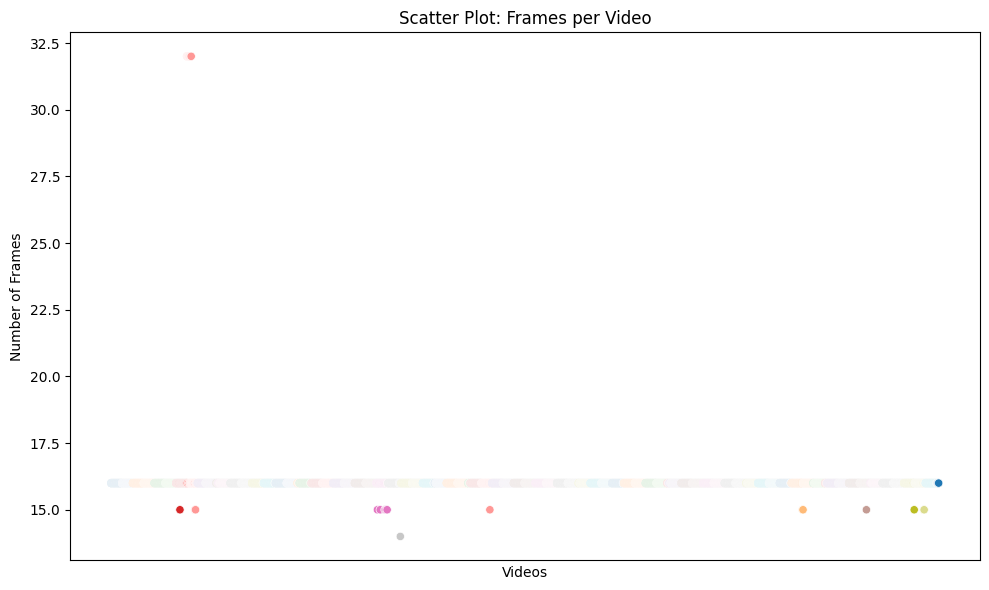

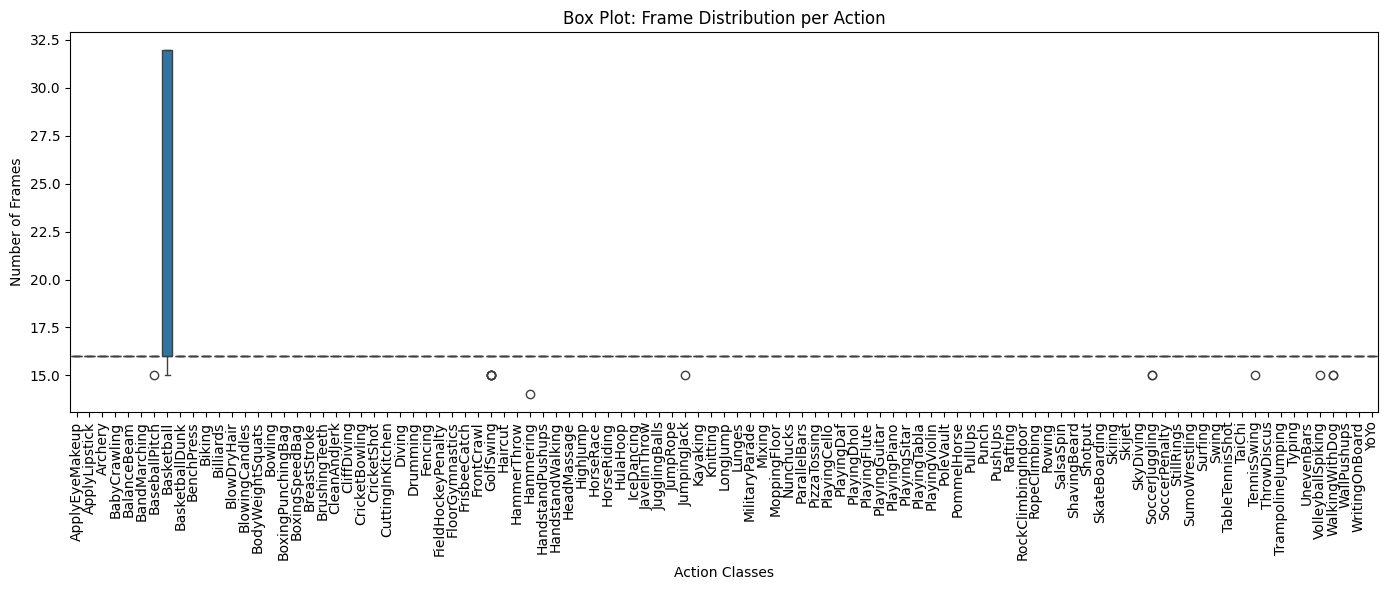

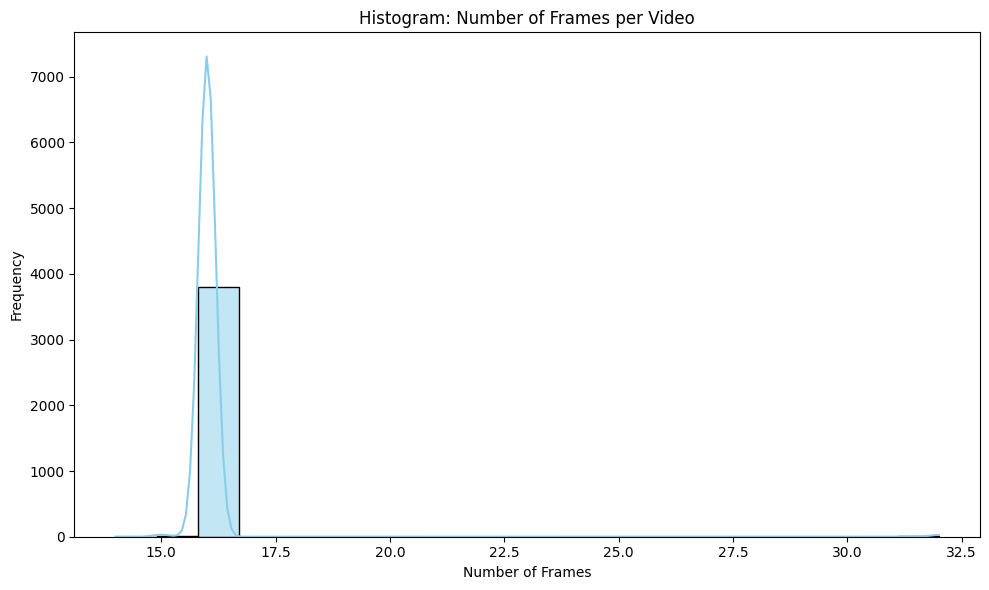

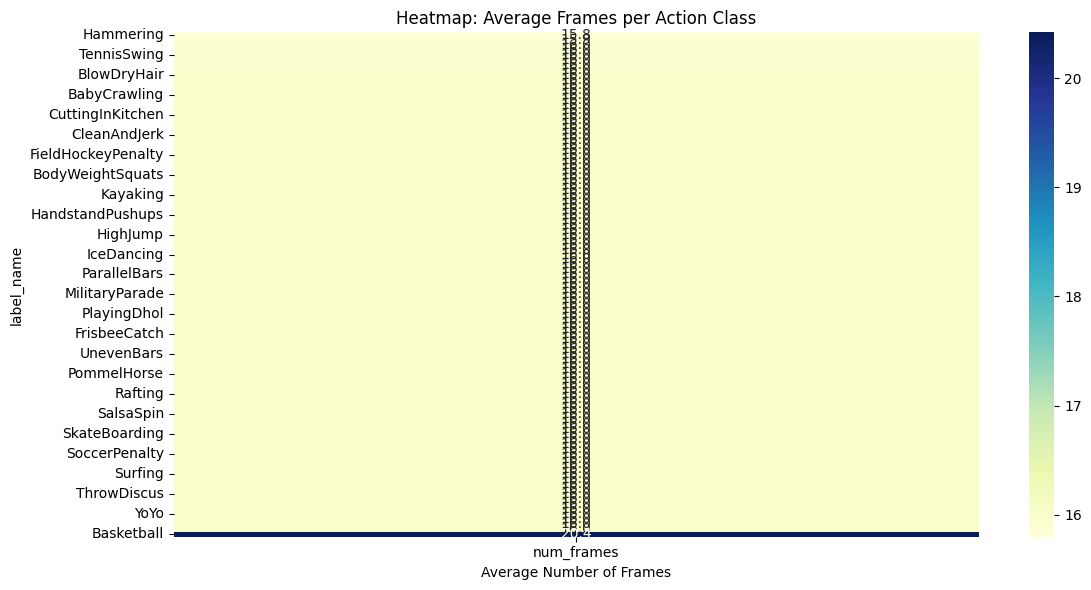


Dataset EDA completed. Plots saved in: /content/drive/MyDrive/MLMiniProject/EDA


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict


dataset_path = "/content/drive/MyDrive/MLMiniProject/full101_dataset"
eda_save_dir = "/content/drive/MyDrive/MLMiniProject/EDA"
os.makedirs(eda_save_dir, exist_ok=True)

from torchvision import datasets

transform = None
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

video_groups = defaultdict(list)
for idx, (path, label) in enumerate(dataset.samples):
    filename = os.path.basename(path)
    video_name = filename.split("_frame")[0]
    video_groups[video_name].append(label)

video_data = []
for video, labels in video_groups.items():
    video_data.append({
        "video_name": video,
        "num_frames": len(labels),
        "label": labels[0]
    })

df = pd.DataFrame(video_data)
df['label_name'] = df['label'].apply(lambda x: dataset.classes[x])

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='video_name', y='num_frames', hue='label_name', palette='tab20', legend=False)
plt.xticks([], [])
plt.xlabel('Videos')
plt.ylabel('Number of Frames')
plt.title('Scatter Plot: Frames per Video')
plt.tight_layout()
plt.savefig(os.path.join(eda_save_dir, "scatter_frames_per_video.png"))
plt.show()

plt.figure(figsize=(14,6))
sns.boxplot(x='label_name', y='num_frames', data=df)
plt.xticks(rotation=90)
plt.xlabel('Action Classes')
plt.ylabel('Number of Frames')
plt.title('Box Plot: Frame Distribution per Action')
plt.tight_layout()
plt.savefig(os.path.join(eda_save_dir, "boxplot_frames_per_class.png"))
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(df['num_frames'], bins=20, kde=True, color='skyblue')
plt.xlabel('Number of Frames')
plt.ylabel('Frequency')
plt.title('Histogram: Number of Frames per Video')
plt.tight_layout()
plt.savefig(os.path.join(eda_save_dir, "histogram_frames.png"))
plt.show()

heatmap_data = df.groupby('label_name')['num_frames'].mean().sort_values().to_frame()
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.xlabel('Average Number of Frames')
plt.title('Heatmap: Average Frames per Action Class')
plt.tight_layout()
plt.savefig(os.path.join(eda_save_dir, "heatmap_avg_frames_per_class.png"))
plt.show()

print(f"\nDataset EDA completed. Plots saved in: {eda_save_dir}")

In [ ]:
import os
import json
import torch

save_dir = "/content/drive/MyDrive/MLMiniProject/Simple_CNN"
os.makedirs(save_dir, exist_ok=True)

pth_path = os.path.join(save_dir, "simplecnn_best.pth")
torch.save(model.state_dict(), pth_path)

print("Model saved as .pth")

json_path = os.path.join(save_dir, "simplecnn_best.json")

model_cpu = model.to("cpu")
state_dict = {k: v.tolist() for k, v in model_cpu.state_dict().items()}

with open(json_path, "w") as f:
    json.dump(state_dict, f)

print("Model saved as JSON")

model.to(device)

print("Saved in:", save_dir)

Model saved as .pth
Model saved as JSON
Saved in: /content/drive/MyDrive/MLMiniProject/Simple_CNN


In [ ]:
print(len(dataset.classes))
print(dataset.classes)

101
['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress', 'Biking', 'Billiards', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats', 'Bowling', 'BoxingPunchingBag', 'BoxingSpeedBag', 'BreastStroke', 'BrushingTeeth', 'CleanAndJerk', 'CliffDiving', 'CricketBowling', 'CricketShot', 'CuttingInKitchen', 'Diving', 'Drumming', 'Fencing', 'FieldHockeyPenalty', 'FloorGymnastics', 'FrisbeeCatch', 'FrontCrawl', 'GolfSwing', 'Haircut', 'HammerThrow', 'Hammering', 'HandstandPushups', 'HandstandWalking', 'HeadMassage', 'HighJump', 'HorseRace', 'HorseRiding', 'HulaHoop', 'IceDancing', 'JavelinThrow', 'JugglingBalls', 'JumpRope', 'JumpingJack', 'Kayaking', 'Knitting', 'LongJump', 'Lunges', 'MilitaryParade', 'Mixing', 'MoppingFloor', 'Nunchucks', 'ParallelBars', 'PizzaTossing', 'PlayingCello', 'PlayingDaf', 'PlayingDhol', 'PlayingFlute', 'PlayingGuitar', 'PlayingPiano', 'PlayingSitar', 'PlayingTabla'

In [ ]:
# Cnn ending

In [ ]:
# ViT starting

In [ ]:
import torch
import torch.nn as nn
import timm

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import numpy as np
import os
from collections import defaultdict

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
dataset_path = "/content/drive/MyDrive/MLMiniProject/processed_dataset/normal"

In [ ]:
train_full = datasets.ImageFolder(dataset_path, transform=train_transform)
test_full  = datasets.ImageFolder(dataset_path, transform=test_transform)

num_classes = len(train_full.classes)
print("Classes:", train_full.classes)

Classes: ['Basketball', 'BenchPress', 'Bowling', 'BoxingPunchingBag', 'CricketShot', 'HammerThrow', 'Punch', 'TennisSwing']


In [ ]:
video_groups = defaultdict(list)

for idx, (path, label) in enumerate(train_full.samples):
    filename = os.path.basename(path)

    video_name = filename.split("_frame")[0]

    video_groups[video_name].append(idx)

video_names = list(video_groups.keys())
np.random.shuffle(video_names)

split = int(0.8 * len(video_names))

train_videos = video_names[:split]
test_videos = video_names[split:]

train_indices = []
test_indices = []

for v in train_videos:
    train_indices.extend(video_groups[v])

for v in test_videos:
    test_indices.extend(video_groups[v])

train_dataset = Subset(train_full, train_indices)
test_dataset  = Subset(test_full, test_indices)

print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))

Train samples: 512
Test samples : 127


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=num_classes
)

for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

model = model.to(device)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import json
import os

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)

best_accuracy = 0.0

checkpoint_path = "/content/MLMiniProject/vit-model/vit_best.pth"
json_checkpoint_path = "/content/drive/MyDrive/MLMiniProject/VIT/vit_best_info.json"

vit_info = {
    "num_classes": model.num_classes,
    "model_name": "vit_base_patch16_224"
}

os.makedirs(os.path.dirname(json_checkpoint_path), exist_ok=True)

with open(json_checkpoint_path, "w") as f:
    json.dump(vit_info, f)

print("ViT model info saved as JSON (weights are in .pth file).")

os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
torch.save(model.state_dict(), checkpoint_path)
print(f"ViT model weights saved at {checkpoint_path}")

ViT model info saved as JSON (weights are in .pth file).
ViT model weights saved at /content/MLMiniProject/vit-model/vit_best.pth


In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch+1}, Loss: {total_loss:.4f}")

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"Validation Accuracy: {acc*100:.2f}%")

    if acc > best_accuracy:
        best_accuracy = acc
        torch.save(model.state_dict(), json_checkpoint_path)
        print("Best ViT model saved!")


Epoch 1, Loss: 20.3654
Validation Accuracy: 73.23%
Best ViT model saved!

Epoch 2, Loss: 18.0879
Validation Accuracy: 73.23%

Epoch 3, Loss: 16.2604
Validation Accuracy: 74.80%
Best ViT model saved!

Epoch 4, Loss: 14.5302
Validation Accuracy: 76.38%
Best ViT model saved!

Epoch 5, Loss: 12.9587
Validation Accuracy: 76.38%

Epoch 6, Loss: 11.3643
Validation Accuracy: 77.17%
Best ViT model saved!

Epoch 7, Loss: 10.5872
Validation Accuracy: 77.17%

Epoch 8, Loss: 9.6256
Validation Accuracy: 79.53%
Best ViT model saved!

Epoch 9, Loss: 8.6727
Validation Accuracy: 79.53%

Epoch 10, Loss: 7.9563
Validation Accuracy: 79.53%


In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc_vit = accuracy_score(all_labels, all_preds)
prec_vit = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec_vit = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1_vit = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"\nFinal Results:")
print(f"Accuracy  : {acc_vit*100:.2f}%")
print(f"Precision : {prec_vit:.4f}")
print(f"Recall    : {rec_vit:.4f}")
print(f"F1 Score  : {f1_vit:.4f}")



Final Results:
Accuracy  : 79.53%
Precision : 0.7063
Recall    : 0.6672
F1 Score  : 0.6661


In [ ]:
print("Classes:", train_full.classes)
print("Total actions:", len(train_full.classes))

Classes: ['Basketball', 'BenchPress', 'Bowling', 'BoxingPunchingBag', 'CricketShot', 'HammerThrow', 'Punch', 'TennisSwing']
Total actions: 8


In [ ]:
#ViT ending

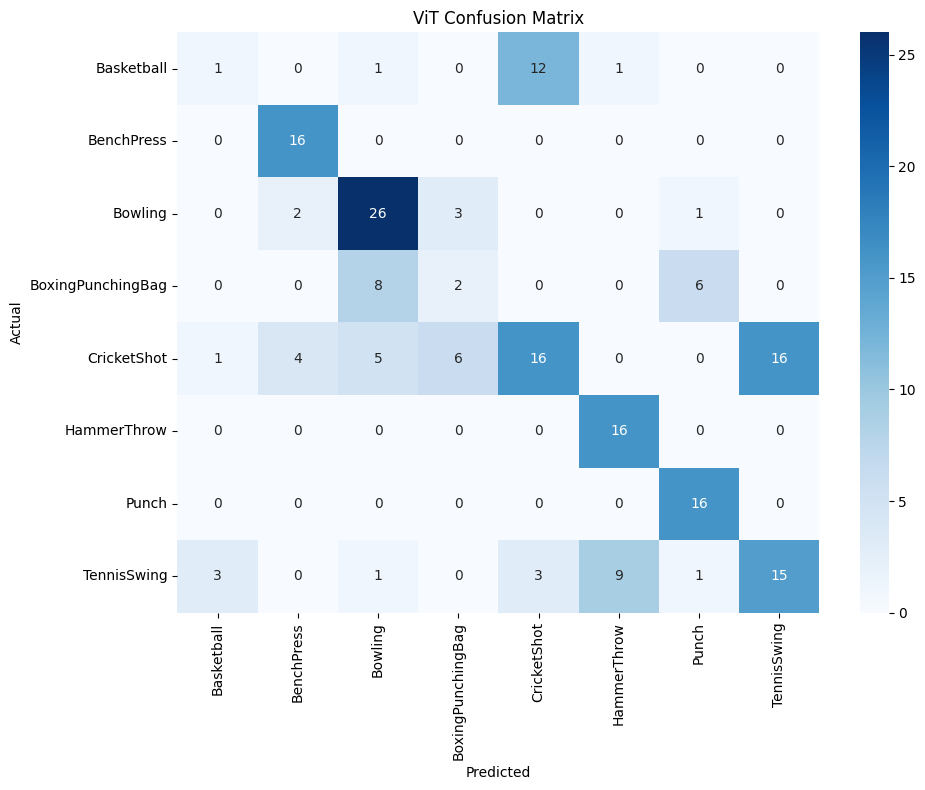

Saved ViT Confusion Matrix at /content/drive/MyDrive/MLMiniProject/Confusion matrix/vit_confusion_matrix.png



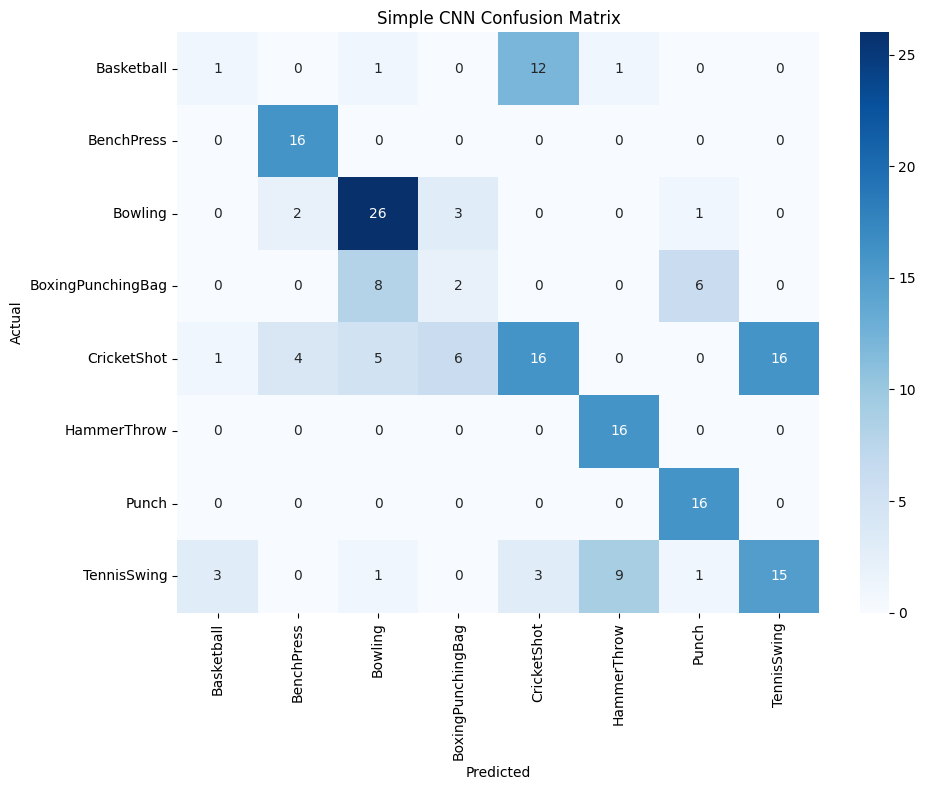

Saved Simple CNN Confusion Matrix at /content/drive/MyDrive/MLMiniProject/Confusion matrix/cnn_confusion_matrix.png



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os

conf_matrix_folder = "/content/drive/MyDrive/MLMiniProject/Confusion matrix"
os.makedirs(conf_matrix_folder, exist_ok=True)

def plot_confusion_matrix(y_true, y_pred, classes, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.savefig(save_path)
    plt.close()
    print(f"Saved {title} at {save_path}\n")

plot_confusion_matrix(
    all_labels,
    all_preds,
    classes=train_full.classes,
    title="ViT Confusion Matrix",
    save_path=os.path.join(conf_matrix_folder, "vit_confusion_matrix.png")
)

all_labels_cnn = []
all_preds_cnn = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_cnn.extend(predicted.cpu().numpy())
        all_labels_cnn.extend(labels.cpu().numpy())

plot_confusion_matrix(
    all_labels_cnn,
    all_preds_cnn,
    classes=dataset.classes,
    title="Simple CNN Confusion Matrix",
    save_path=os.path.join(conf_matrix_folder, "cnn_confusion_matrix.png")
)

In [ ]:
import pandas as pd
import os

cnn_accuracy = accuracy_cnn
cnn_precision = precision_cnn
cnn_recall = recall_cnn
cnn_f1 = f1_cnn

vit_accuracy = acc_vit
vit_precision = prec_vit
vit_recall = rec_vit
vit_f1 = f1_vit

data = {
    "Model": ["Simple CNN", "ViT"],
    "Accuracy (%)": [round(cnn_accuracy * 100, 2), round(vit_accuracy * 100, 2)],
    "Precision": [round(cnn_precision, 4), round(vit_precision, 4)],
    "Recall": [round(cnn_recall, 4), round(vit_recall, 4)],
    "F1 Score": [round(cnn_f1, 4), round(vit_f1, 4)]
}

df = pd.DataFrame(data)

print("\nFinal Results Table:\n")
display(df)

save_path = "/content/drive/MyDrive/MLMiniProject/full101_results/results_restnet_vit_101_models.csv"
df.to_csv(save_path, index=False)

print(f"\nTable also saved at: {save_path}")


Final Results Table:



,Model,Accuracy (%),Precision,Recall,F1 Score
0,Simple CNN,52.36,0.5677,0.5236,0.5144
1,ViT,79.53,0.7063,0.6672,0.6661



Table also saved at: /content/drive/MyDrive/MLMiniProject/full101_results/results_restnet_vit_101_models.csv


In [ ]:
# ============================================================
# FULL UCF101 - 101 Classes, 5 Videos Each, 16 Frames Each
# 80:20 Train/Test Split (4 train, 1 test per class)
# ============================================================
!pip install -q evaluate scikit-learn
!pip install -q accelerate transformers
import os
import cv2
import numpy as np
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader, Subset
from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification,
    TrainingArguments,
    Trainer
)
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# ── 1. CONFIG ──────────────────────────────────────────────
DATASET_CSV       = os.path.join(path, 'train.csv')   # your existing `path` variable
VIDEO_BASE_PATH   = path
OUTPUT_MINI_DIR   = "/content/drive/MyDrive/MLMiniProject/full101_dataset"
MODEL_SAVE_DIR    = "/content/drive/MyDrive/MLMiniProject/videomae-full101"
RESULTS_SAVE_DIR  = "/content/drive/MyDrive/MLMiniProject/full101_results"
NUM_FRAMES        = 16
VIDEOS_PER_CLASS  = 5
TRAIN_VIDEOS      = 4   # 80%
TEST_VIDEOS       = 1   # 20%
BATCH_SIZE        = 2
NUM_EPOCHS        = 5
LEARNING_RATE     = 5e-5
MODEL_CKPT        = "MCG-NJU/videomae-base-finetuned-kinetics"

os.makedirs(OUTPUT_MINI_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR,  exist_ok=True)
os.makedirs(RESULTS_SAVE_DIR, exist_ok=True)

# ── 2. SELECT 5 VIDEOS PER CLASS (ALL 101 CLASSES) ─────────
print("📋 Loading dataset CSV...")
df_all = pd.read_csv(DATASET_CSV)
all_classes = sorted(df_all['label'].unique())
print(f"   Total classes found: {len(all_classes)}")

selected_rows = (
    df_all[df_all['label'].isin(all_classes)]
    .groupby('label')
    .head(VIDEOS_PER_CLASS)
    .reset_index(drop=True)
)
print(f"   Total videos selected: {len(selected_rows)}  "
      f"(target: {len(all_classes) * VIDEOS_PER_CLASS})")

# ── 3. EXTRACT FRAMES ──────────────────────────────────────
def extract_frames_to_disk(video_path, save_folder, num_frames=16):
    """Extract `num_frames` evenly spaced frames from a video."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < num_frames:
        cap.release()
        return False
    indices = np.linspace(0, total - 1, num_frames, dtype=int)
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            cap.release()
            return False
        frame = cv2.resize(frame, (224, 224))
        cv2.imwrite(os.path.join(save_folder, f"{video_name}_frame_{i}.jpg"), frame)
    cap.release()
    return True

print("\n🎬 Extracting frames...")
skipped = 0
for _, row in selected_rows.iterrows():
    label        = row['label']
    relative     = row['clip_path'].lstrip("/")
    video_path   = os.path.join(VIDEO_BASE_PATH, relative)
    class_folder = os.path.join(OUTPUT_MINI_DIR, label)
    os.makedirs(class_folder, exist_ok=True)
    ok = extract_frames_to_disk(video_path, class_folder, NUM_FRAMES)
    if not ok:
        print(f"  ⚠️  Skipped (too short): {video_path}")
        skipped += 1

print(f"   Done. Skipped {skipped} short videos.")

# ── 4. DATASET CLASS ───────────────────────────────────────
class UCF101FullDataset(Dataset):
    def __init__(self, root_dir, processor, num_frames=16):
        self.processor   = processor
        self.num_frames  = num_frames
        self.classes     = sorted(os.listdir(root_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples     = []   # list of (frame_path_list, label_idx)

        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            frames      = sorted(os.listdir(cls_dir))
            video_names = sorted(set(f.split('_frame_')[0] for f in frames))
            for vid in video_names:
                vid_frames = [
                    os.path.join(cls_dir, f"{vid}_frame_{i}.jpg")
                    for i in range(num_frames)
                ]
                if all(os.path.exists(f) for f in vid_frames):
                    self.samples.append((vid_frames, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, label = self.samples[idx]
        video = []
        for p in frame_paths:
            img = cv2.imread(p)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            video.append(img)
        inputs = self.processor(video, return_tensors="pt")
        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'label': torch.tensor(label)
        }

# ── 5. BUILD TRAIN / TEST SPLITS (4 train, 1 test per class) ─
print("\n🔀 Building train/test splits...")
processor = VideoMAEImageProcessor.from_pretrained(MODEL_CKPT)
full_dataset = UCF101FullDataset(OUTPUT_MINI_DIR, processor, NUM_FRAMES)

print(f"   Total valid video clips: {len(full_dataset)}")
print(f"   Classes in dataset:      {len(full_dataset.classes)}")

# Group sample indices by class
from collections import defaultdict
class_indices = defaultdict(list)
for idx, (_, label_idx) in enumerate(full_dataset.samples):
    class_indices[label_idx].append(idx)

train_indices, test_indices = [], []
for label_idx, idxs in class_indices.items():
    np.random.shuffle(idxs)          # shuffle within class
    train_indices.extend(idxs[:TRAIN_VIDEOS])
    test_indices.extend(idxs[TRAIN_VIDEOS:TRAIN_VIDEOS + TEST_VIDEOS])

train_dataset = Subset(full_dataset, train_indices)
test_dataset  = Subset(full_dataset, test_indices)
print(f"   Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

# ── 6. MODEL ───────────────────────────────────────────────
print("\n🤖 Loading VideoMAE model...")
id2label = {i: c for c, i in full_dataset.class_to_idx.items()}
label2id = full_dataset.class_to_idx

model = VideoMAEForVideoClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=len(full_dataset.classes),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# ── 7. TRAINING ────────────────────────────────────────────
def collate_fn(examples):
    pixel_values = torch.stack([e["pixel_values"] for e in examples])
    labels       = torch.tensor([e["label"] for e in examples])
    return {"pixel_values": pixel_values, "labels": labels}

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    return accuracy_metric.compute(predictions=preds, references=eval_pred.label_ids)

training_args = TrainingArguments(
    output_dir                  = MODEL_SAVE_DIR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    num_train_epochs            = NUM_EPOCHS,
    weight_decay                = 0.01,
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    remove_unused_columns       = False,
    fp16                        = True,       # faster on T4/A100
    logging_dir                 = os.path.join(MODEL_SAVE_DIR, "logs"),
    logging_steps               = 5,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics,
    data_collator   = collate_fn,
)

print("\n🚀 Starting training...")
train_result = trainer.train()

# ── 8. EVALUATE & SAVE RESULTS ─────────────────────────────
print("\n📊 Evaluating on test set...")
eval_result = trainer.evaluate(test_dataset)
print("Eval results:", eval_result)

# --- Per-class classification report ---
all_preds, all_labels = [], []
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         collate_fn=collate_fn, shuffle=False)
with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        outputs      = model(pixel_values=pixel_values)
        preds        = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch["labels"].numpy())

class_names   = [id2label[i] for i in range(len(id2label))]
report_str    = classification_report(all_labels, all_preds,
                                      target_names=class_names, digits=4)
print(report_str)

# --- Save text report ---
timestamp     = datetime.now().strftime("%Y%m%d_%H%M%S")
report_path   = os.path.join(RESULTS_SAVE_DIR, f"classification_report_{timestamp}.txt")
with open(report_path, "w") as f:
    f.write(f"Evaluation Results  —  {timestamp}\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Overall Accuracy : {eval_result['eval_accuracy']:.4f}\n")
    f.write(f"Eval Loss        : {eval_result['eval_loss']:.4f}\n\n")
    f.write(report_str)
    f.write("\n\nTraining Summary\n" + "=" * 60 + "\n")
    f.write(str(train_result))
print(f"   ✅ Report saved → {report_path}")

# --- Save per-epoch accuracy CSV ---
epoch_log     = trainer.state.log_history
epoch_df      = pd.DataFrame([e for e in epoch_log if 'eval_accuracy' in e])
csv_path      = os.path.join(RESULTS_SAVE_DIR, f"epoch_accuracy_{timestamp}.csv")
epoch_df.to_csv(csv_path, index=False)
print(f"   ✅ Epoch log saved → {csv_path}")

# --- Confusion matrix (saved as PNG) ---
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, annot_kws={"size": 6})
ax.set_ylabel('Ground Truth',  fontweight='bold')
ax.set_xlabel('Predicted',     fontweight='bold')
ax.set_title(f'Confusion Matrix — VideoMAE (All 101 Classes)', fontsize=14)
plt.tight_layout()
cm_path = os.path.join(RESULTS_SAVE_DIR, f"confusion_matrix_{timestamp}.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"   ✅ Confusion matrix saved → {cm_path}")

# --- Epoch accuracy curve ---
if not epoch_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(epoch_df['epoch'], epoch_df['eval_accuracy'], marker='o', linewidth=2)
    plt.title("Validation Accuracy per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.tight_layout()
    curve_path = os.path.join(RESULTS_SAVE_DIR, f"accuracy_curve_{timestamp}.png")
    plt.savefig(curve_path, dpi=150)
    plt.show()
    print(f"   ✅ Accuracy curve saved → {curve_path}")

print("\n🎉 All done! Results saved to:", RESULTS_SAVE_DIR)

In [ ]:
#Start
!pip install -q evaluate scikit-learn
!pip install -q accelerate transformers

import os
import cv2
import numpy as np
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader, Subset
from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification,
    TrainingArguments,
    Trainer
)
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from datetime import datetime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00


In [ ]:
# ── 1. CONFIG ──────────────────────────────────────────────
path              = "/content/drive/MyDrive/MLMiniProject/archive"
DATASET_CSV       = os.path.join(path, 'train.csv')
VIDEO_BASE_PATH   = path
OUTPUT_MINI_DIR   = "/content/drive/MyDrive/MLMiniProject/full101_dataset"
MODEL_SAVE_DIR    = "/content/drive/MyDrive/MLMiniProject/videomae-full101"
RESULTS_SAVE_DIR  = "/content/drive/MyDrive/MLMiniProject/full101_results"
NUM_FRAMES        = 16
VIDEOS_PER_CLASS  = 50
TRAIN_VIDEOS      = 40   # 80%
TEST_VIDEOS       = 10   # 20%
BATCH_SIZE        = 2
NUM_EPOCHS        = 10
LEARNING_RATE     = 5e-5
MODEL_CKPT        = "MCG-NJU/videomae-base-finetuned-kinetics"

os.makedirs(OUTPUT_MINI_DIR,  exist_ok=True)
os.makedirs(MODEL_SAVE_DIR,   exist_ok=True)
os.makedirs(RESULTS_SAVE_DIR, exist_ok=True)

In [ ]:













# ── 2. SELECT 5 VIDEOS PER CLASS (ALL 101 CLASSES) ─────────
print("📋 Loading dataset CSV...")
df_all = pd.read_csv(DATASET_CSV)
all_classes = sorted(df_all['label'].unique())
print(f"   Total classes found: {len(all_classes)}")

selected_rows = (
    df_all[df_all['label'].isin(all_classes)]
    .groupby('label')
    .head(VIDEOS_PER_CLASS)
    .reset_index(drop=True)
)
print(f"   Total videos selected: {len(selected_rows)}  "
      f"(target: {len(all_classes) * VIDEOS_PER_CLASS})")


📋 Loading dataset CSV...
   Total classes found: 101
   Total videos selected: 5050  (target: 5050)


In [ ]:
def extract_frames_to_disk(video_path, save_folder, num_frames=16):
    cap    = cv2.VideoCapture(video_path)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < num_frames:
        cap.release()
        return False
    indices    = np.linspace(0, total - 1, num_frames, dtype=int)
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            cap.release()
            return False
        frame = cv2.resize(frame, (224, 224))
        cv2.imwrite(os.path.join(save_folder, f"{video_name}_frame_{i}.jpg"), frame)
    cap.release()
    return True

In [ ]:
# ── 3. EXTRACT FRAMES ──────────────────────────────────────


print("\n🎬 Extracting frames...")
skipped = 0
for _, row in selected_rows.iterrows():
    label        = row['label']
    relative     = row['clip_path'].lstrip("/")
    video_path   = os.path.join(VIDEO_BASE_PATH, relative)
    class_folder = os.path.join(OUTPUT_MINI_DIR, label)
    os.makedirs(class_folder, exist_ok=True)
    ok = extract_frames_to_disk(video_path, class_folder, NUM_FRAMES)
    if not ok:
        print(f"  ⚠️  Skipped (too short): {video_path}")
        skipped += 1
print(f"   Done. Skipped {skipped} short videos.")


🎬 Extracting frames...


In [ ]:
# ── 4. DATASET CLASS ───────────────────────────────────────
class UCF101FullDataset(Dataset):
    def __init__(self, root_dir, processor, num_frames=16):
        self.processor    = processor
        self.num_frames   = num_frames
        self.classes      = sorted(os.listdir(root_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples      = []

        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            frames      = sorted(os.listdir(cls_dir))
            video_names = sorted(set(f.split('_frame_')[0] for f in frames))
            for vid in video_names:
                vid_frames = [
                    os.path.join(cls_dir, f"{vid}_frame_{i}.jpg")
                    for i in range(num_frames)
                ]
                if all(os.path.exists(f) for f in vid_frames):
                    self.samples.append((vid_frames, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, label = self.samples[idx]
        video = []
        for p in frame_paths:
            img = cv2.imread(p)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            video.append(img)
        inputs = self.processor(video, return_tensors="pt")
        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'label': torch.tensor(label)
        }

In [ ]:
# ── 5. BUILD TRAIN / TEST SPLITS (4 train, 1 test per class) ─
print("\n🔀 Building train/test splits...")
processor    = VideoMAEImageProcessor.from_pretrained(MODEL_CKPT)
full_dataset = UCF101FullDataset(OUTPUT_MINI_DIR, processor, NUM_FRAMES)

print(f"   Total valid video clips: {len(full_dataset)}")
print(f"   Classes in dataset:      {len(full_dataset.classes)}")

class_indices = defaultdict(list)
for idx, (_, label_idx) in enumerate(full_dataset.samples):
    class_indices[label_idx].append(idx)

train_indices, test_indices = [], []
for label_idx, idxs in class_indices.items():
    np.random.shuffle(idxs)
    train_indices.extend(idxs[:TRAIN_VIDEOS])
    test_indices.extend(idxs[TRAIN_VIDEOS:TRAIN_VIDEOS + TEST_VIDEOS])

train_dataset = Subset(full_dataset, train_indices)
test_dataset  = Subset(full_dataset, test_indices)
print(f"   Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")




🔀 Building train/test splits...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

   Total valid video clips: 3823
   Classes in dataset:      101
   Train samples: 3099 | Test samples: 724


In [ ]:
# ── 6. MODEL ───────────────────────────────────────────────
print("\n🤖 Loading VideoMAE model...")
id2label = {i: c for c, i in full_dataset.class_to_idx.items()}
label2id = full_dataset.class_to_idx

model = VideoMAEForVideoClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=len(full_dataset.classes),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)


🤖 Loading VideoMAE model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base-finetuned-kinetics
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400]) vs model:torch.Size([101])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400, 768]) vs model:torch.Size([101, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
# ── 7. TRAINING ────────────────────────────────────────────
def collate_fn(examples):
    pixel_values = torch.stack([e["pixel_values"] for e in examples])
    labels       = torch.tensor([e["label"] for e in examples])
    return {"pixel_values": pixel_values, "labels": labels}

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    return accuracy_metric.compute(predictions=preds, references=eval_pred.label_ids)

training_args = TrainingArguments(
    output_dir                  = MODEL_SAVE_DIR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    num_train_epochs            = NUM_EPOCHS,
    weight_decay                = 0.01,
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    remove_unused_columns       = False,
    fp16                        = True,
    logging_steps               = 5,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics,
    data_collator   = collate_fn,
)

print("\n🚀 Starting training...")
train_result = trainer.train()


🚀 Starting training...


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# ── 8. EVALUATE & SAVE RESULTS ─────────────────────────────
print("\n📊 Evaluating on test set...")
eval_result = trainer.evaluate(test_dataset)
print("Eval results:", eval_result)

# --- Per-class predictions ---
all_preds, all_labels = [], []
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         collate_fn=collate_fn, shuffle=False)
with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        outputs      = model(pixel_values=pixel_values)
        preds        = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch["labels"].numpy())

In [ ]:

# ── FIX: use only labels present in test set ──────────────
unique_labels = sorted(set(all_labels))
class_names   = [id2label[i] for i in unique_labels]
report_str    = classification_report(all_labels, all_preds,
                                      labels=unique_labels,
                                      target_names=class_names, digits=4)
print(report_str)

# --- Save text report ---
timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")
report_path = os.path.join(RESULTS_SAVE_DIR, f"classification_report_{timestamp}.txt")
with open(report_path, "w") as f:
    f.write(f"Evaluation Results  —  {timestamp}\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Overall Accuracy : {eval_result['eval_accuracy']:.4f}\n")
    f.write(f"Eval Loss        : {eval_result['eval_loss']:.4f}\n\n")
    f.write(report_str)
    f.write("\n\nTraining Summary\n" + "=" * 60 + "\n")
    f.write(str(train_result))
print(f"   ✅ Report saved → {report_path}")

In [ ]:
# --- Save per-epoch accuracy CSV ---
epoch_log = trainer.state.log_history
epoch_df  = pd.DataFrame([e for e in epoch_log if 'eval_accuracy' in e])
csv_path  = os.path.join(RESULTS_SAVE_DIR, f"epoch_accuracy_{timestamp}.csv")
epoch_df.to_csv(csv_path, index=False)
print(f"   ✅ Epoch log saved → {csv_path}")

In [ ]:
# --- Confusion matrix ---
cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, annot_kws={"size": 6})
ax.set_ylabel('Ground Truth',  fontweight='bold')
ax.set_xlabel('Predicted',     fontweight='bold')
ax.set_title('Confusion Matrix — VideoMAE (All 101 Classes)', fontsize=14)
plt.tight_layout()
cm_path = os.path.join(RESULTS_SAVE_DIR, f"confusion_matrix_{timestamp}.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"   ✅ Confusion matrix saved → {cm_path}")

In [ ]:
# --- Accuracy curve ---
if not epoch_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(epoch_df['epoch'], epoch_df['eval_accuracy'], marker='o', linewidth=2)
    plt.title("Validation Accuracy per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.tight_layout()
    curve_path = os.path.join(RESULTS_SAVE_DIR, f"accuracy_curve_{timestamp}.png")
    plt.savefig(curve_path, dpi=150)
    plt.show()
    print(f" Accuracy curve saved → {curve_path}")

print("\n🎉 All done! Results saved to:", RESULTS_SAVE_DIR)

# Swin T


  SECTION 1 — SYSTEM ENVIRONMENT & CONFIGURATION

  Device      : cuda
  GPU         : Tesla T4
  VRAM        : 15.6 GB
  CUDA caps   : SM 7.5
  PyTorch     : 2.10.0+cu128
  Torchvision : 0.25.0+cu128
  NumPy       : 2.0.2
  Seed        : 42

  Action classes (8):
    [0] Basketball
    [1] BenchPress
    [2] Bowling
    [3] BoxingPunchingBag
    [4] CricketShot
    [5] HammerThrow
    [6] Punch
    [7] TennisSwing

  SECTION 2 — EXPLORATORY DATA ANALYSIS

[2.1] Class distribution...
            Class  Frames
       BenchPress      80
          Bowling      80
BoxingPunchingBag      80
      CricketShot      80
            Punch      80
      HammerThrow      80
      TennisSwing      80
       Basketball      79

  Total frames  : 639
  Max / class   : 80  (BenchPress)
  Min / class   : 79  (Basketball)
  Mean / class  : 79.9


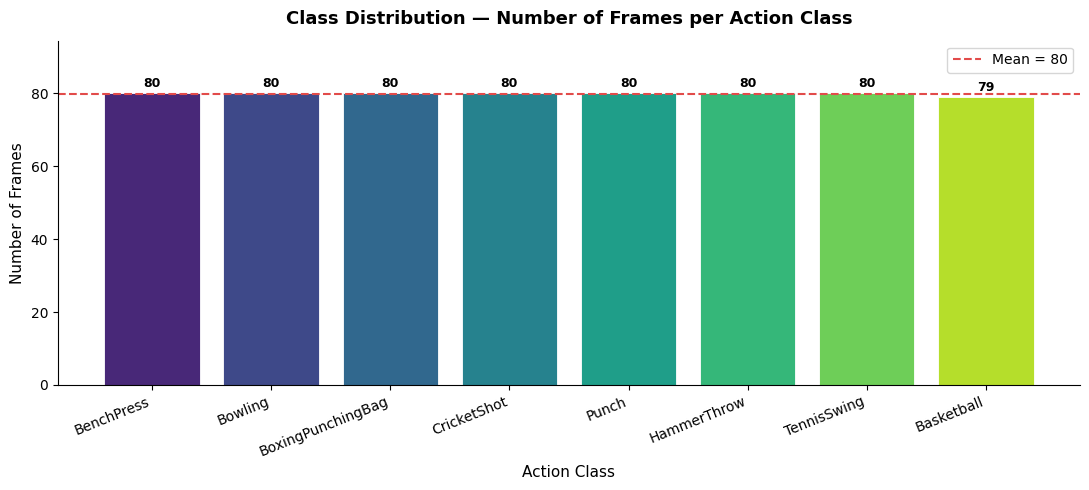

  ✓ Saved: eda_01_class_distribution.png

[2.2] Sample frames per class...


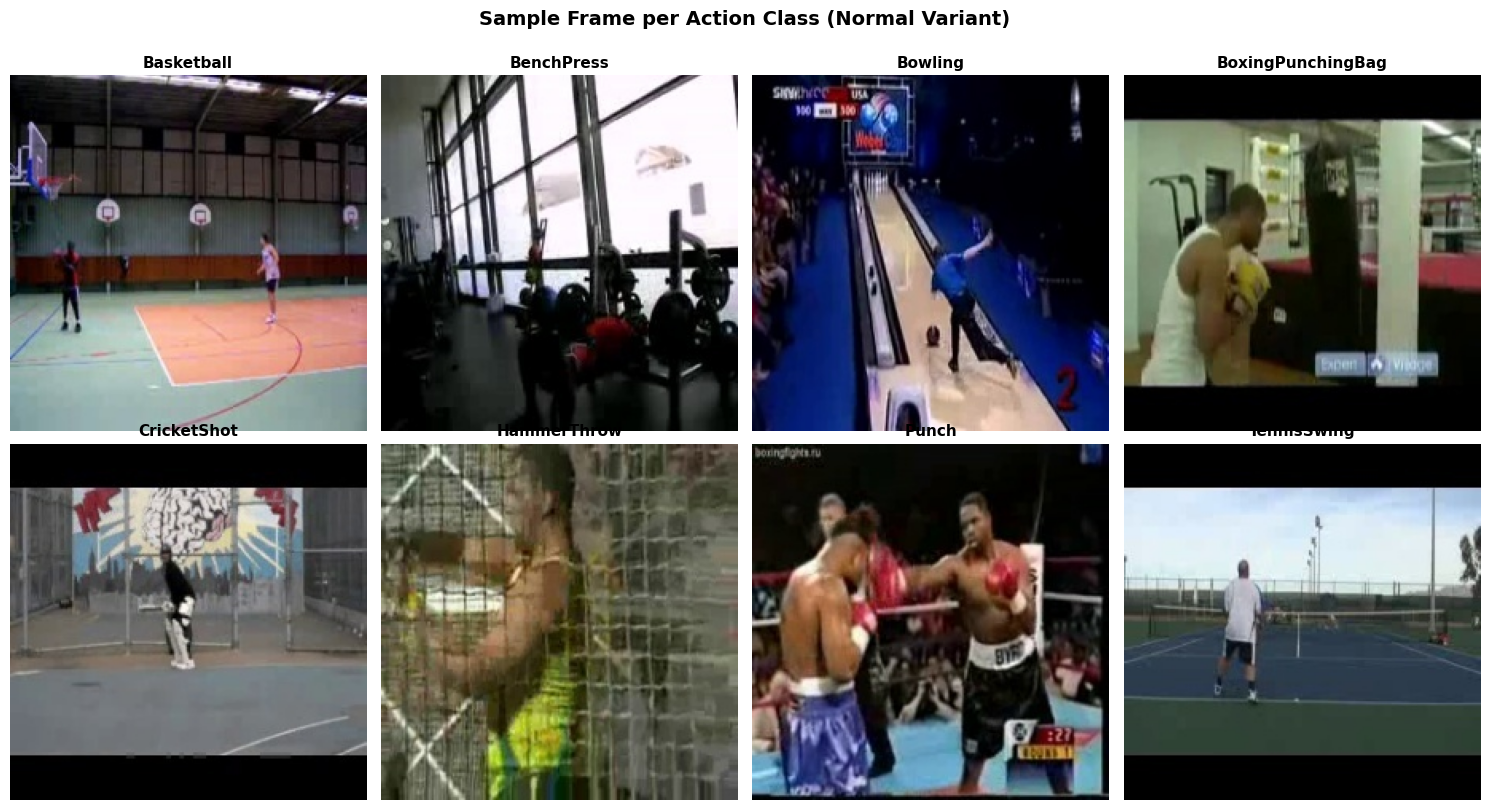

  ✓ Saved: eda_02_sample_frames.png

[2.3] Preprocessing variants (Normal / Low Light / Motion Blur / Occlusion)...


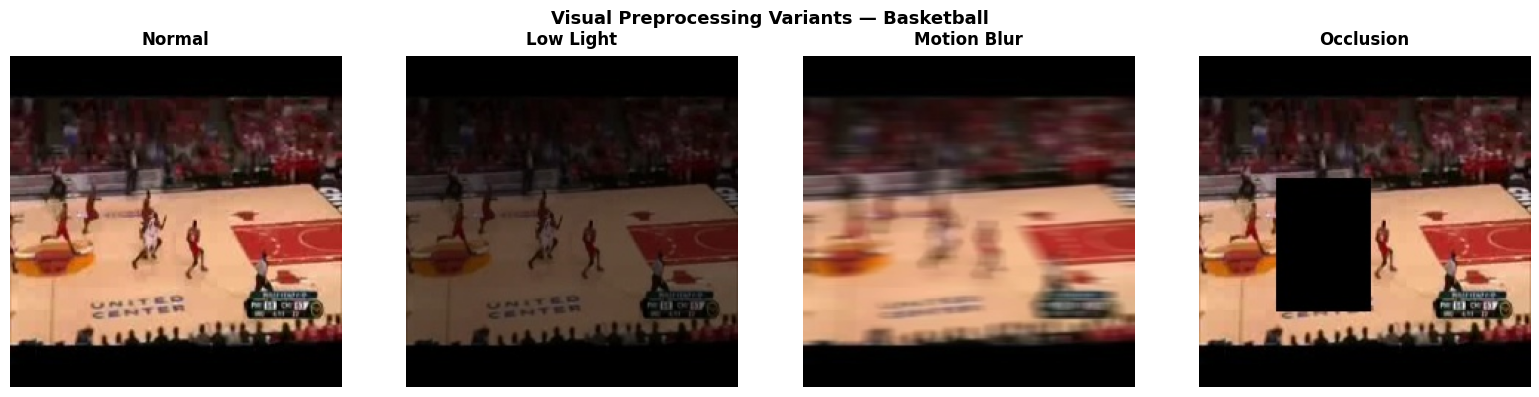

  ✓ Saved: eda_03_preprocessing_variants.png

[2.4] Pixel intensity distributions per channel...


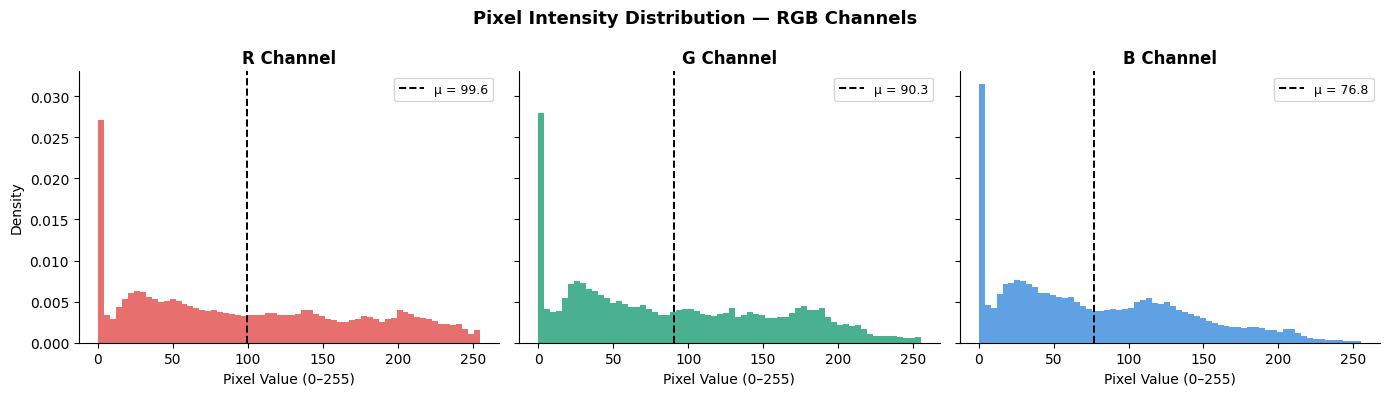

  ✓ Saved: eda_04_pixel_intensity.png

[2.5] Mean frame per class (temporal average)...


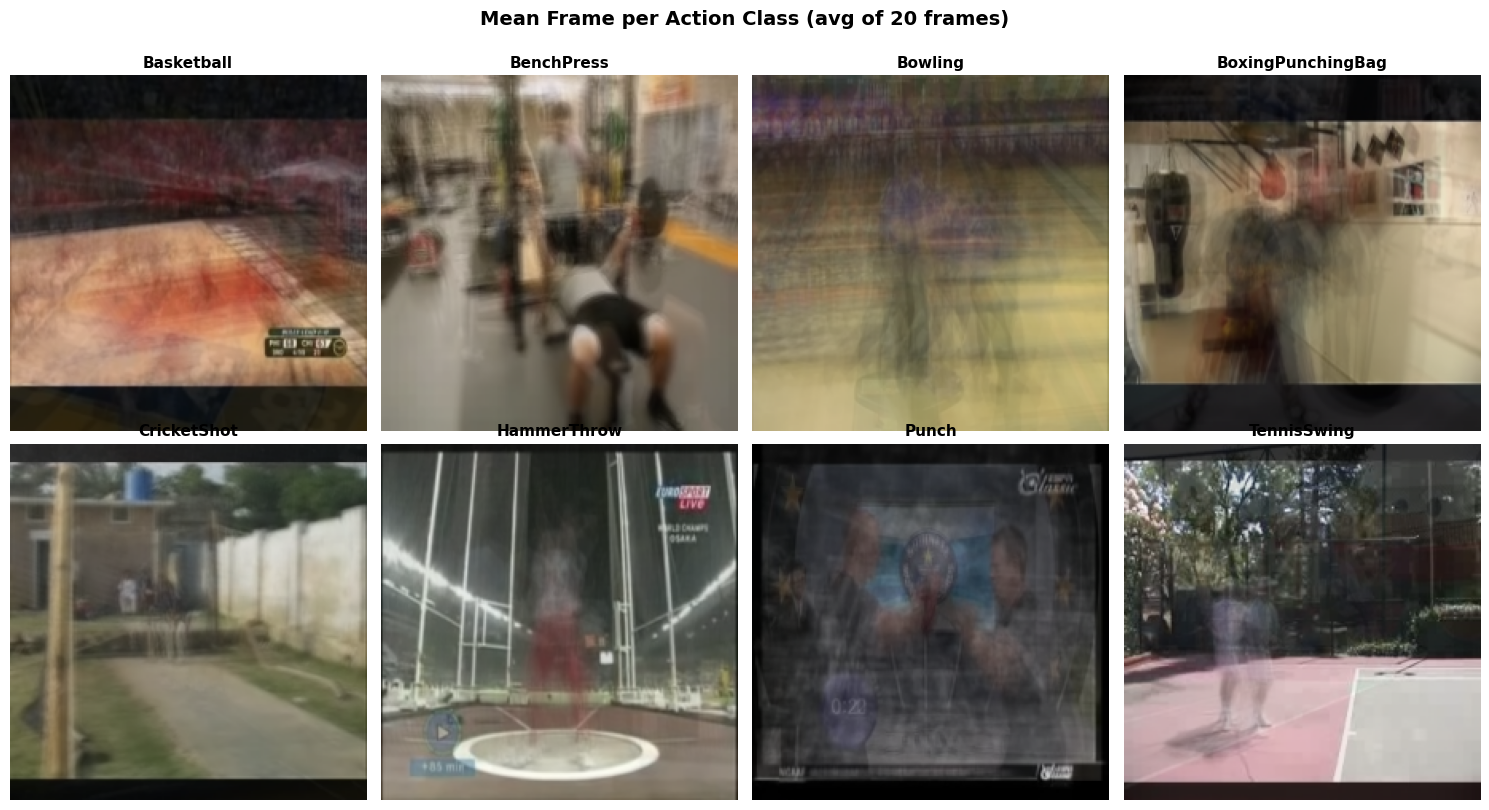

  ✓ Saved: eda_05_mean_frames.png

[2.6] Brightness comparison across preprocessing variants...


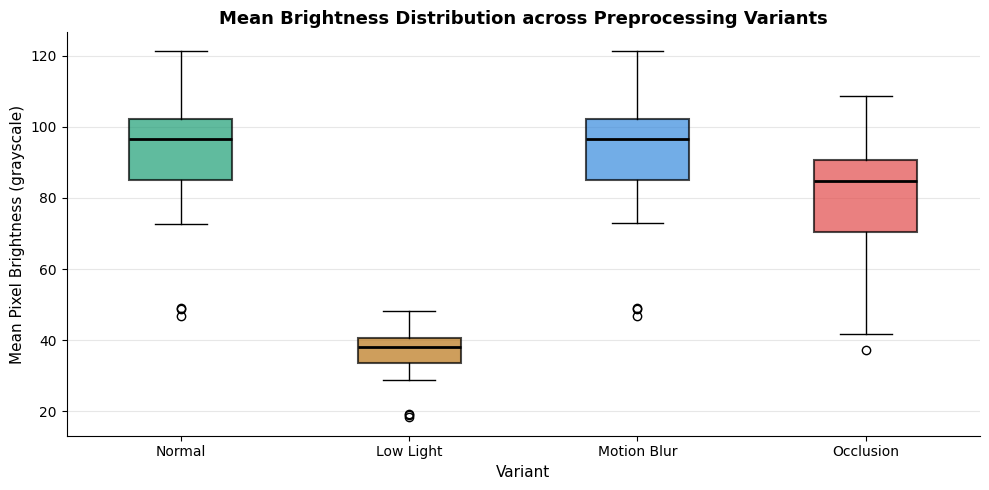

  ✓ Saved: eda_06_brightness_boxplot.png

[2.7] Dataset split summary...
      Split  Videos  Frames
Train (80%)      32     511
 Test (20%)       8     128


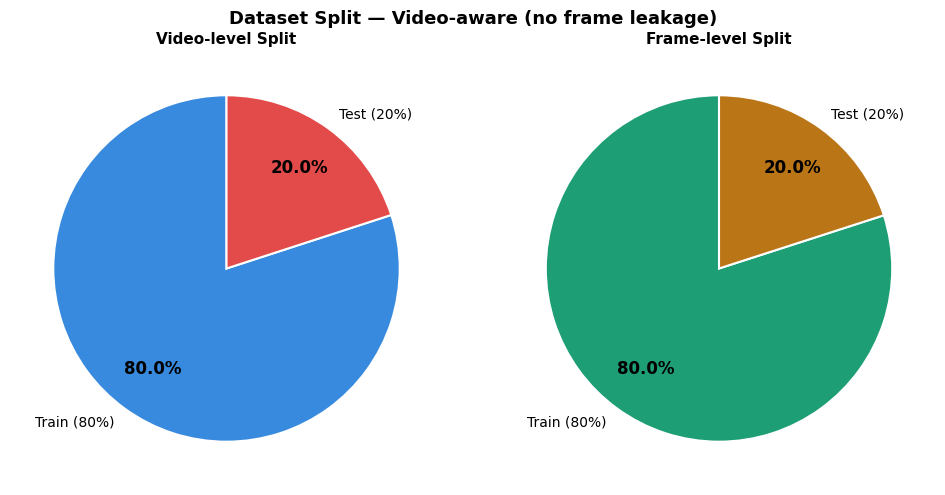

  ✓ Saved: eda_07_split_pie.png

[2.8] Frames per video distribution...


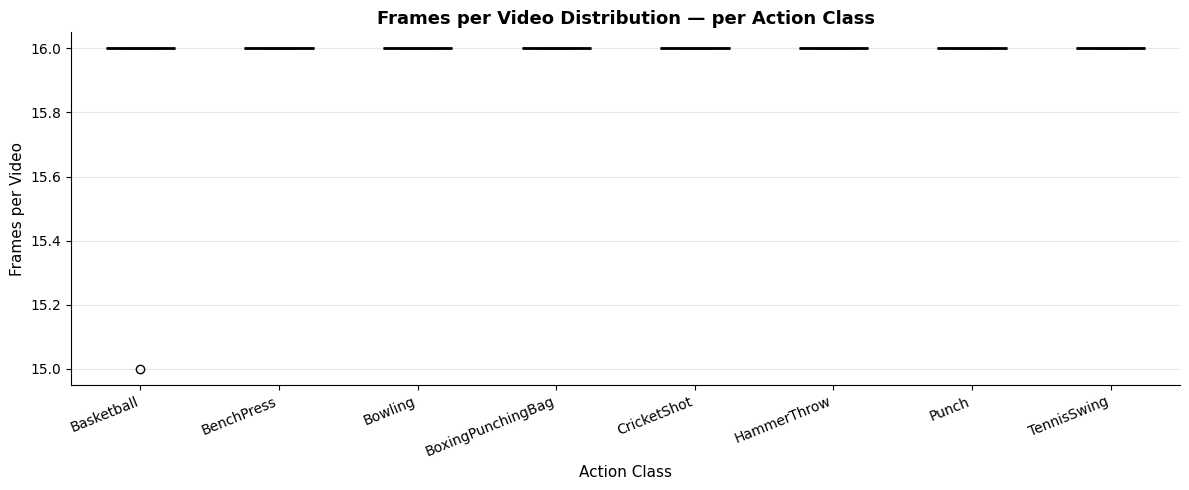

  ✓ Saved: eda_08_frames_per_video.png

  SECTION 3 — MODEL ARCHITECTURE

  Architecture Summary:
          Parameter                              Value
           Backbone  Swin Transformer Tiny (Microsoft)
         Input size             224 × 224 (3 channels)
         Patch size                              4 × 4
        Window size                              7 × 7
          Embed dim                                 96
       Stage depths                      2 – 2 – 6 – 2
    Attention heads                    3 – 6 – 12 – 24
Classification head                    Linear(768 → 8)
      Pretrained on                        ImageNet-1K
 Fine-tune strategy          All layers, layer-wise LR
   Total parameters                            27.53 M
   Trainable params                            27.53 M
     Output classes                                  8
          Optimiser                    AdamW (wd=0.05)
      LR (backbone)                               3e-5
          LR (head)   

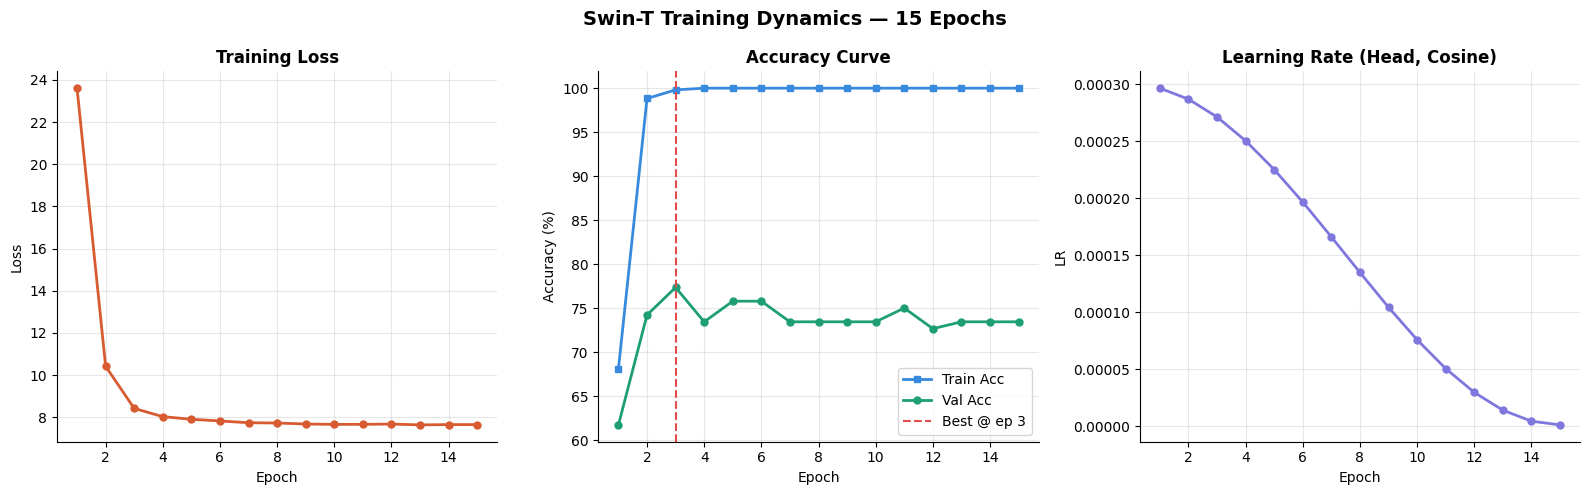

  ✓ Saved: training_01_curves.png


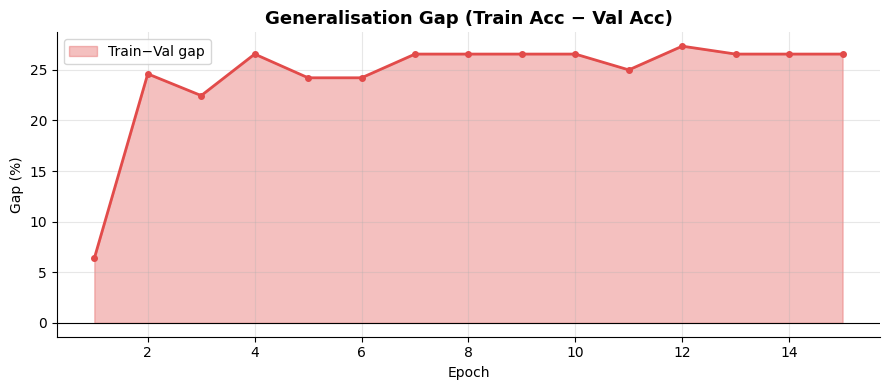

  ✓ Saved: training_02_gap.png

  SECTION 6 — FINAL EVALUATION

  Accuracy  : 77.34%
  Precision : 0.8797
  Recall    : 0.7734
  F1 Score  : 0.7781
  ✓ Saved: metrics.json

  SECTION 7 — CONFUSION MATRIX


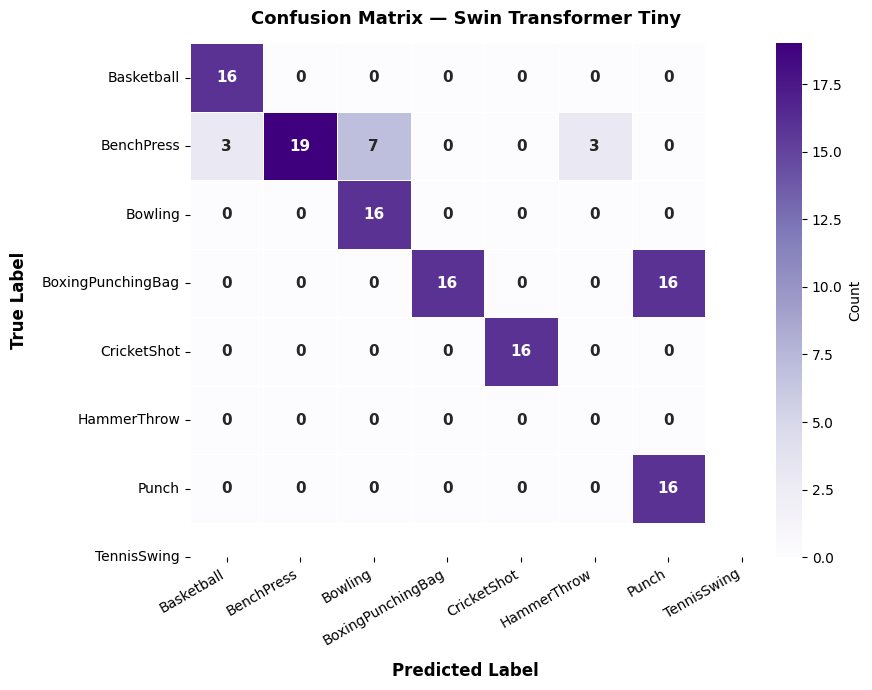

  ✓ Saved: eval_01_confusion_matrix.png


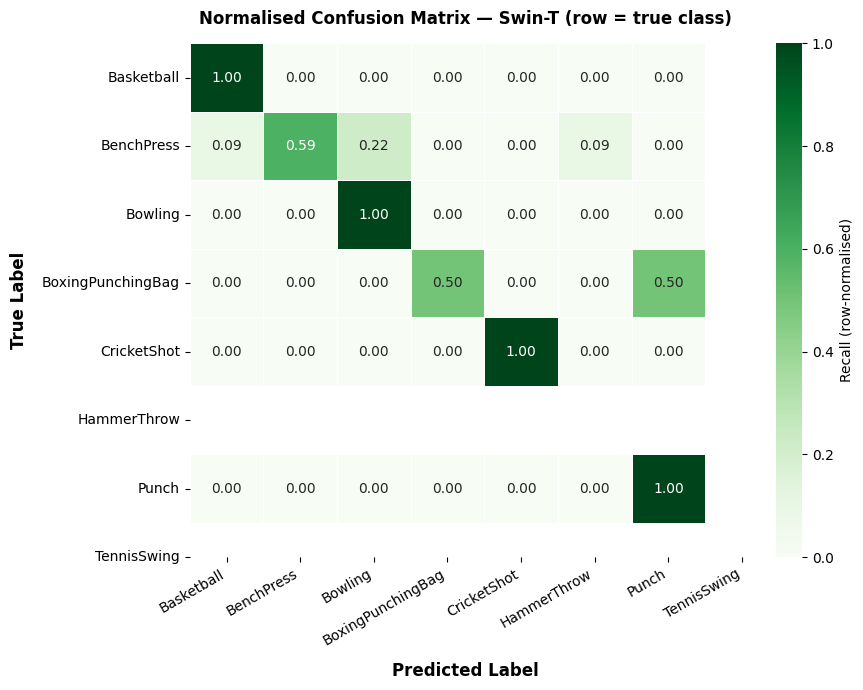

  ✓ Saved: eval_02_confusion_matrix_norm.png


In [ ]:
# ================================================================
#   SWIN TRANSFORMER TINY — Human Action Recognition
#   UCF-101 | 8-Class Mini Dataset
#   Includes: EDA + Training + Full Inference Visuals
# ================================================================

# ── IMPORTS ─────────────────────────────────────────────────────
import os
import cv2
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from collections import defaultdict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False})

# ── REPRODUCIBILITY ──────────────────────────────────────────────
SEED = 42
random.seed(SEED);  np.random.seed(SEED)
torch.manual_seed(SEED);  torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── PATHS ────────────────────────────────────────────────────────
DATASET_PATH = "/content/drive/MyDrive/MLMiniProject/processed_dataset/normal"
PROC_PATH    = "/content/drive/MyDrive/MLMiniProject/processed_dataset"
SAVE_DIR     = "/content/drive/MyDrive/MLMiniProject/SwinT"
os.makedirs(SAVE_DIR, exist_ok=True)

VARIANTS     = ["normal", "low_light", "motion_blur", "occlusion"]
VARIANT_LBLS = ["Normal", "Low Light", "Motion Blur", "Occlusion"]


# ================================================================
#  SECTION 1 — SYSTEM ENVIRONMENT
# ================================================================
print("=" * 60)
print("  SECTION 1 — SYSTEM ENVIRONMENT & CONFIGURATION")
print("=" * 60)

print(f"\n  Device      : {device}")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"  GPU         : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM        : {props.total_memory / 1e9:.1f} GB")
    print(f"  CUDA caps   : SM {props.major}.{props.minor}")
print(f"  PyTorch     : {torch.__version__}")
print(f"  Torchvision : {__import__('torchvision').__version__}")
print(f"  NumPy       : {np.__version__}")
print(f"  Seed        : {SEED}")

# quick dataset probe to get classes
_probe   = datasets.ImageFolder(DATASET_PATH)
CLASS_NAMES = _probe.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"\n  Action classes ({NUM_CLASSES}):")
for i, c in enumerate(CLASS_NAMES):
    print(f"    [{i}] {c}")


# ================================================================
#  SECTION 2 — EDA
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 2 — EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# ── 2.1  Class Distribution ──────────────────────────────────────
print("\n[2.1] Class distribution...")

class_counts = defaultdict(int)
for _, label in _probe.samples:
    class_counts[CLASS_NAMES[label]] += 1

counts_df = (pd.DataFrame({"Class": list(class_counts.keys()),
                            "Frames": list(class_counts.values())})
               .sort_values("Frames", ascending=False)
               .reset_index(drop=True))

print(counts_df.to_string(index=False))
print(f"\n  Total frames  : {counts_df['Frames'].sum()}")
print(f"  Max / class   : {counts_df['Frames'].max()}  ({counts_df.iloc[0]['Class']})")
print(f"  Min / class   : {counts_df['Frames'].min()}  ({counts_df.iloc[-1]['Class']})")
print(f"  Mean / class  : {counts_df['Frames'].mean():.1f}")

palette = sns.color_palette("viridis", NUM_CLASSES)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(counts_df["Class"], counts_df["Frames"],
              color=palette, edgecolor="white", linewidth=0.6)
for bar, val in zip(bars, counts_df["Frames"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            str(val), ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.axhline(counts_df["Frames"].mean(), color="#E24B4A",
           linestyle="--", linewidth=1.5,
           label=f"Mean = {counts_df['Frames'].mean():.0f}")
ax.set_title("Class Distribution — Number of Frames per Action Class",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Action Class", fontsize=11)
ax.set_ylabel("Number of Frames", fontsize=11)
ax.set_ylim(0, counts_df["Frames"].max() * 1.18)
ax.legend(fontsize=10)
plt.xticks(rotation=22, ha="right", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eda_01_class_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eda_01_class_distribution.png")


# ── 2.2  Sample Frame Grid ───────────────────────────────────────
print("\n[2.2] Sample frames per class...")

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()
for i, cls in enumerate(sorted(CLASS_NAMES)):
    cls_dir = os.path.join(DATASET_PATH, cls)
    frames  = sorted(os.listdir(cls_dir))
    frame_p = os.path.join(cls_dir, frames[len(frames) // 2])
    img     = cv2.cvtColor(cv2.imread(frame_p), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=11, fontweight="bold", pad=6)
    axes[i].axis("off")
    for spine in axes[i].spines.values():
        spine.set_visible(False)

fig.suptitle("Sample Frame per Action Class (Normal Variant)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eda_02_sample_frames.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eda_02_sample_frames.png")


# ── 2.3  Preprocessing Variants ─────────────────────────────────
print("\n[2.3] Preprocessing variants (Normal / Low Light / Motion Blur / Occlusion)...")

ref_cls  = "Basketball"
ref_file = sorted(os.listdir(os.path.join(PROC_PATH, "normal", ref_cls)))[0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, v, lbl in zip(axes, VARIANTS, VARIANT_LBLS):
    p   = os.path.join(PROC_PATH, v, ref_cls, ref_file)
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(lbl, fontsize=12, fontweight="bold", pad=8)
    ax.axis("off")
    # coloured border per variant
    border_colors = ["#1D9E75", "#BA7517", "#378ADD", "#E24B4A"]
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(border_colors[VARIANTS.index(v)])
        spine.set_linewidth(3)

fig.suptitle(f"Visual Preprocessing Variants — {ref_cls}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eda_03_preprocessing_variants.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eda_03_preprocessing_variants.png")


# ── 2.4  Pixel Intensity Histogram ──────────────────────────────
print("\n[2.4] Pixel intensity distributions per channel...")

channels = {"R": [], "G": [], "B": []}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATASET_PATH, cls)
    for f in sorted(os.listdir(cls_dir))[:5]:          # 5 frames per class
        img = cv2.cvtColor(cv2.imread(os.path.join(cls_dir, f)),
                           cv2.COLOR_BGR2RGB)
        channels["R"].extend(img[:, :, 0].flatten().tolist())
        channels["G"].extend(img[:, :, 1].flatten().tolist())
        channels["B"].extend(img[:, :, 2].flatten().tolist())

ch_colors = {"R": "#E24B4A", "G": "#1D9E75", "B": "#378ADD"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (ch, color) in zip(axes, ch_colors.items()):
    ax.hist(channels[ch], bins=64, color=color, alpha=0.80,
            density=True, edgecolor="none")
    ax.axvline(np.mean(channels[ch]), color="black",
               linestyle="--", linewidth=1.4,
               label=f"μ = {np.mean(channels[ch]):.1f}")
    ax.set_title(f"{ch} Channel", fontsize=12, fontweight="bold")
    ax.set_xlabel("Pixel Value (0–255)", fontsize=10)
    ax.legend(fontsize=9)
axes[0].set_ylabel("Density", fontsize=10)
fig.suptitle("Pixel Intensity Distribution — RGB Channels",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eda_04_pixel_intensity.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eda_04_pixel_intensity.png")


# ── 2.5  Mean Image per Class ────────────────────────────────────
print("\n[2.5] Mean frame per class (temporal average)...")

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()
for i, cls in enumerate(sorted(CLASS_NAMES)):
    cls_dir = os.path.join(DATASET_PATH, cls)
    frames  = sorted(os.listdir(cls_dir))[:20]
    accum   = np.zeros((224, 224, 3), dtype=np.float64)
    for f in frames:
        accum += cv2.cvtColor(cv2.imread(os.path.join(cls_dir, f)),
                              cv2.COLOR_BGR2RGB).astype(np.float64)
    mean_img = (accum / len(frames)).astype(np.uint8)
    axes[i].imshow(mean_img)
    axes[i].set_title(cls, fontsize=11, fontweight="bold")
    axes[i].axis("off")

fig.suptitle("Mean Frame per Action Class (avg of 20 frames)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eda_05_mean_frames.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eda_05_mean_frames.png")


# ── 2.6  Brightness Distribution across Variants ────────────────
print("\n[2.6] Brightness comparison across preprocessing variants...")

mean_brightness = {v: [] for v in VARIANTS}
for cls in CLASS_NAMES:
    for v in VARIANTS:
        cls_dir = os.path.join(PROC_PATH, v, cls)
        for f in sorted(os.listdir(cls_dir))[:3]:
            img = cv2.imread(os.path.join(cls_dir, f),
                             cv2.IMREAD_GRAYSCALE)
            mean_brightness[v].append(img.mean())

brt_colors = ["#1D9E75", "#BA7517", "#378ADD", "#E24B4A"]
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([mean_brightness[v] for v in VARIANTS],
           labels=VARIANT_LBLS, patch_artist=True,
           boxprops=dict(linewidth=1.5),
           medianprops=dict(linewidth=2, color="black"))
for patch, color in zip(ax.patches, brt_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.70)
ax.set_title("Mean Brightness Distribution across Preprocessing Variants",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Mean Pixel Brightness (grayscale)", fontsize=11)
ax.set_xlabel("Variant", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eda_06_brightness_boxplot.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eda_06_brightness_boxplot.png")


# ── 2.7  Dataset Split Summary ───────────────────────────────────
print("\n[2.7] Dataset split summary...")

_all    = datasets.ImageFolder(DATASET_PATH)
vgroups = defaultdict(list)
for idx, (p, _) in enumerate(_all.samples):
    vgroups[os.path.basename(p).split("_frame")[0]].append(idx)

all_vids   = list(vgroups.keys())
n_train_v  = int(0.8 * len(all_vids))
n_test_v   = len(all_vids) - n_train_v
n_train_f  = sum(len(vgroups[v]) for v in all_vids[:n_train_v])
n_test_f   = sum(len(vgroups[v]) for v in all_vids[n_train_v:])

split_df = pd.DataFrame({
    "Split":   ["Train (80%)", "Test (20%)"],
    "Videos":  [n_train_v,    n_test_v],
    "Frames":  [n_train_f,    n_test_f],
})
print(split_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
split_colors = [["#378ADD", "#E24B4A"], ["#1D9E75", "#BA7517"]]
for ax, col, title, colors in zip(
        axes,
        ["Videos", "Frames"],
        ["Video-level Split", "Frame-level Split"],
        split_colors):
    wedges, texts, pcts = ax.pie(
        split_df[col], labels=split_df["Split"],
        autopct="%1.1f%%", colors=colors,
        startangle=90, pctdistance=0.72,
        wedgeprops=dict(linewidth=1.5, edgecolor="white"))
    for p in pcts:
        p.set_fontsize(12); p.set_fontweight("bold")
    ax.set_title(title, fontsize=11, fontweight="bold")

fig.suptitle("Dataset Split — Video-aware (no frame leakage)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eda_07_split_pie.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eda_07_split_pie.png")


# ── 2.8  Frames per Video (temporal length analysis) ────────────
print("\n[2.8] Frames per video distribution...")

frames_per_vid = {cls: [] for cls in CLASS_NAMES}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATASET_PATH, cls)
    all_fr  = sorted(os.listdir(cls_dir))
    vid_fr  = defaultdict(int)
    for f in all_fr:
        vid_fr[f.split("_frame")[0]] += 1
    frames_per_vid[cls] = list(vid_fr.values())

fig, ax = plt.subplots(figsize=(12, 5))
data_to_plot  = [frames_per_vid[c] for c in sorted(CLASS_NAMES)]
bp = ax.boxplot(data_to_plot, labels=sorted(CLASS_NAMES),
                patch_artist=True, notch=False,
                medianprops=dict(linewidth=2, color="black"))
colors_bp = sns.color_palette("viridis", NUM_CLASSES)
for patch, color in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_title("Frames per Video Distribution — per Action Class",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Frames per Video", fontsize=11)
ax.set_xlabel("Action Class", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=22, ha="right", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eda_08_frames_per_video.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eda_08_frames_per_video.png")


# ================================================================
#  SECTION 3 — MODEL ARCHITECTURE
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 3 — MODEL ARCHITECTURE")
print("=" * 60)

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_full = datasets.ImageFolder(DATASET_PATH, transform=train_transform)
test_full  = datasets.ImageFolder(DATASET_PATH, transform=test_transform)
CLASS_NAMES  = train_full.classes
NUM_CLASSES  = len(CLASS_NAMES)

# video-aware 80/20 split
video_groups = defaultdict(list)
for idx, (path, _) in enumerate(train_full.samples):
    vid = os.path.basename(path).split("_frame")[0]
    video_groups[vid].append(idx)

video_names = list(video_groups.keys())
np.random.shuffle(video_names)
split      = int(0.8 * len(video_names))
train_idx  = [i for v in video_names[:split] for i in video_groups[v]]
test_idx   = [i for v in video_names[split:] for i in video_groups[v]]

train_dataset = Subset(train_full, train_idx)
test_dataset  = Subset(test_full,  test_idx)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,
                           num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                           num_workers=2, pin_memory=True)

# build Swin-T
swin = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
swin.head = nn.Linear(swin.head.in_features, NUM_CLASSES)
swin = swin.to(device)

total_p     = sum(p.numel() for p in swin.parameters()) / 1e6
trainable_p = sum(p.numel() for p in swin.parameters()
                  if p.requires_grad) / 1e6

arch_info = {
    "Backbone":           "Swin Transformer Tiny (Microsoft)",
    "Input size":         "224 × 224 (3 channels)",
    "Patch size":         "4 × 4",
    "Window size":        "7 × 7",
    "Embed dim":          "96",
    "Stage depths":       "2 – 2 – 6 – 2",
    "Attention heads":    "3 – 6 – 12 – 24",
    "Classification head":f"Linear(768 → {NUM_CLASSES})",
    "Pretrained on":      "ImageNet-1K",
    "Fine-tune strategy": "All layers, layer-wise LR",
    "Total parameters":   f"{total_p:.2f} M",
    "Trainable params":   f"{trainable_p:.2f} M",
    "Output classes":     str(NUM_CLASSES),
    "Optimiser":          "AdamW (wd=0.05)",
    "LR (backbone)":      "3e-5",
    "LR (head)":          "3e-4",
    "Scheduler":          "Cosine Annealing",
    "Loss":               "CrossEntropy + label_smoothing=0.1",
    "Grad clip":          "max_norm = 1.0",
    "Batch size":         "32",
    "Epochs":             "15",
}

print("\n  Architecture Summary:")
arch_df = pd.DataFrame({"Parameter": list(arch_info.keys()),
                         "Value":     list(arch_info.values())})
print(arch_df.to_string(index=False))

print(f"\n  Train samples : {len(train_dataset)}")
print(f"  Test  samples : {len(test_dataset)}")


# ================================================================
#  SECTION 4 — TRAINING
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 4 — TRAINING")
print("=" * 60)

backbone_params = [p for n, p in swin.named_parameters() if "head" not in n]
head_params     = [p for n, p in swin.named_parameters() if "head"     in n]

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": 3e-5},
    {"params": head_params,     "lr": 3e-4},
], weight_decay=0.05)

EPOCHS    = 15
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                  T_max=EPOCHS,
                                                  eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_acc  = 0.0
history   = {"train_loss": [], "train_acc": [], "val_acc": [], "lr": []}

print(f"\n  {'Epoch':>5} | {'Train Loss':>11} | {'Train Acc':>10} | "
      f"{'Val Acc':>9} | {'LR (head)':>11}")
print("  " + "-" * 60)

for epoch in range(EPOCHS):
    # ── train ────────────────────────────────────────────────────
    swin.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = swin(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(swin.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    scheduler.step()
    train_acc = correct / total
    curr_lr   = optimizer.param_groups[1]["lr"]  # head LR

    # ── validate ─────────────────────────────────────────────────
    swin.eval()
    preds_ep, labels_ep = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            preds_ep.extend(torch.argmax(swin(imgs), 1).cpu().numpy())
            labels_ep.extend(labels.numpy())

    val_acc = accuracy_score(labels_ep, preds_ep)

    history["train_loss"].append(total_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(curr_lr)

    tag = ""
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(swin.state_dict(),
                   os.path.join(SAVE_DIR, "swint_best.pth"))
        tag = "  ✓"

    print(f"  {epoch+1:>5} | {total_loss:>11.4f} | "
          f"{train_acc*100:>9.2f}% | {val_acc*100:>8.2f}%{tag} | "
          f"{curr_lr:.2e}")

print(f"\n  Best validation accuracy : {best_acc*100:.2f}%")


# ================================================================
#  SECTION 5 — TRAINING CURVES
#  (matches Section 4.2 of the outputs doc — Loss + Accuracy)
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 5 — TRAINING CURVES")
print("=" * 60)

ep = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss
axes[0].plot(ep, history["train_loss"], marker="o",
             color="#D85A30", linewidth=2, markersize=5)
axes[0].set_title("Training Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(ep, [v * 100 for v in history["train_acc"]],
             marker="s", color="#378ADD", linewidth=2,
             markersize=5, label="Train Acc")
axes[1].plot(ep, [v * 100 for v in history["val_acc"]],
             marker="o", color="#1D9E75", linewidth=2,
             markersize=5, label="Val Acc")
axes[1].set_title("Accuracy Curve", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

# Best val line
best_ep = history["val_acc"].index(max(history["val_acc"])) + 1
axes[1].axvline(best_ep, color="#E24B4A",
                linestyle="--", linewidth=1.5,
                label=f"Best @ ep {best_ep}")
axes[1].legend(fontsize=10)

# LR schedule
axes[2].plot(ep, history["lr"], marker="o", color="#7F77DD",
             linewidth=2, markersize=5)
axes[2].set_title("Learning Rate (Head, Cosine)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].grid(alpha=0.3)

fig.suptitle("Swin-T Training Dynamics — 15 Epochs",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_01_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: training_01_curves.png")

# Gap plot (overfitting monitor)
fig, ax = plt.subplots(figsize=(9, 4))
gap = [t - v for t, v in zip(history["train_acc"], history["val_acc"])]
ax.fill_between(ep, 0, [g * 100 for g in gap],
                alpha=0.35, color="#E24B4A", label="Train−Val gap")
ax.plot(ep, [g * 100 for g in gap], color="#E24B4A",
        linewidth=2, marker="o", markersize=4)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Generalisation Gap (Train Acc − Val Acc)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Gap (%)")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_02_gap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: training_02_gap.png")


# ================================================================
#  SECTION 6 — FINAL EVALUATION (best checkpoint)
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 6 — FINAL EVALUATION")
print("=" * 60)

swin.load_state_dict(torch.load(os.path.join(SAVE_DIR, "swint_best.pth")))
swin.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs  = imgs.to(device)
        logits = swin(imgs)
        probs  = torch.softmax(logits, dim=1)
        all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)

acc_swin  = accuracy_score(all_labels, all_preds)
prec_swin = precision_score(all_labels, all_preds,
                             average="weighted", zero_division=0)
rec_swin  = recall_score(all_labels, all_preds,
                          average="weighted", zero_division=0)
f1_swin   = f1_score(all_labels, all_preds,
                      average="weighted", zero_division=0)

print(f"\n  Accuracy  : {acc_swin*100:.2f}%")
print(f"  Precision : {prec_swin:.4f}")
print(f"  Recall    : {rec_swin:.4f}")
print(f"  F1 Score  : {f1_swin:.4f}")

# save metrics JSON
metrics = {"accuracy": round(acc_swin, 4),
           "precision": round(prec_swin, 4),
           "recall": round(rec_swin, 4),
           "f1_score": round(f1_swin, 4)}
with open(os.path.join(SAVE_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print("  ✓ Saved: metrics.json")


# ================================================================
#  SECTION 7 — CONFUSION MATRIX
#  (matches Section 5.1 of the outputs doc)
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 7 — CONFUSION MATRIX")
print("=" * 60)

cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# ── 7a raw count ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.6, linecolor="white",
            annot_kws={"size": 11, "weight": "bold"},
            cbar_kws={"label": "Count"}, ax=ax)
ax.set_xlabel("Predicted Label",  fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("True Label",       fontsize=12, fontweight="bold", labelpad=10)
ax.set_title("Confusion Matrix — Swin Transformer Tiny",
             fontsize=13, fontweight="bold", pad=14)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(rotation=0,             fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eval_01_confusion_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eval_01_confusion_matrix.png")

# ── 7b normalised (row = recall per class) ────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            vmin=0, vmax=1,
            linewidths=0.6, linecolor="white",
            annot_kws={"size": 10},
            cbar_kws={"label": "Recall (row-normalised)"}, ax=ax)
ax.set_xlabel("Predicted Label",  fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("True Label",       fontsize=12, fontweight="bold", labelpad=10)
ax.set_title("Normalised Confusion Matrix — Swin-T (row = true class)",
             fontsize=12, fontweight="bold", pad=14)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(rotation=0,             fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eval_02_confusion_matrix_norm.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eval_02_confusion_matrix_norm.png")





  SECTION 8 — CLASSIFICATION REPORT
                   precision    recall  f1-score   support

       Basketball       0.00      0.00      0.00         0
       BenchPress       0.84      1.00      0.91        16
          Bowling       1.00      0.59      0.75        32
BoxingPunchingBag       0.70      1.00      0.82        16
      CricketShot       1.00      0.50      0.67        32
      HammerThrow       1.00      1.00      1.00        16
            Punch       0.00      0.00      0.00         0
      TennisSwing       0.50      1.00      0.67        16

         accuracy                           0.77       128
        macro avg       0.63      0.64      0.60       128
     weighted avg       0.88      0.77      0.78       128



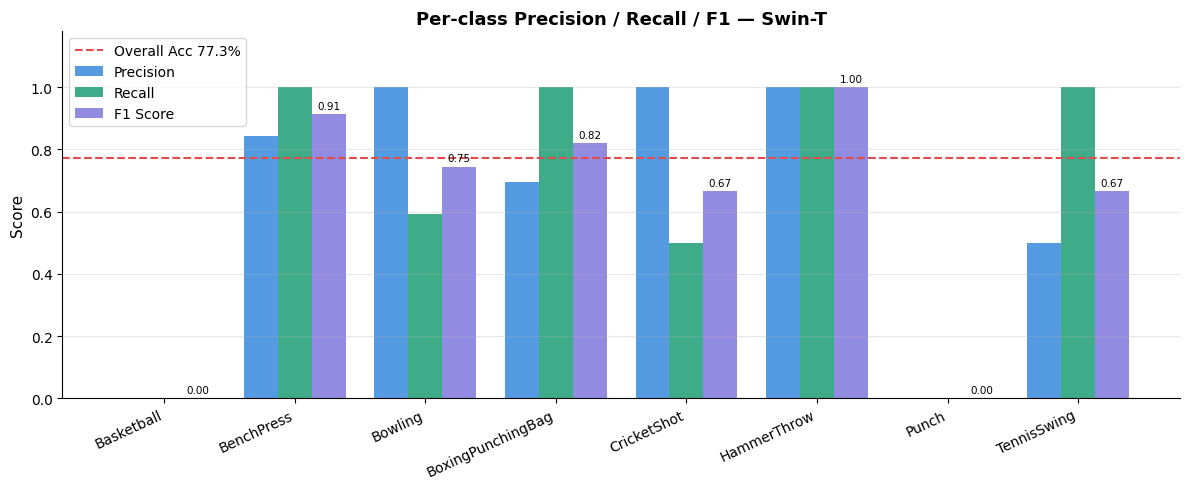

  ✓ Saved: eval_03_per_class_metrics.png

  SECTION 9 — TOP-K ACCURACY

  Top-1 Accuracy : 77.34%
  Top-2 Accuracy : 80.47%
  Top-3 Accuracy : 86.72%
  Top-5 Accuracy : 89.84%


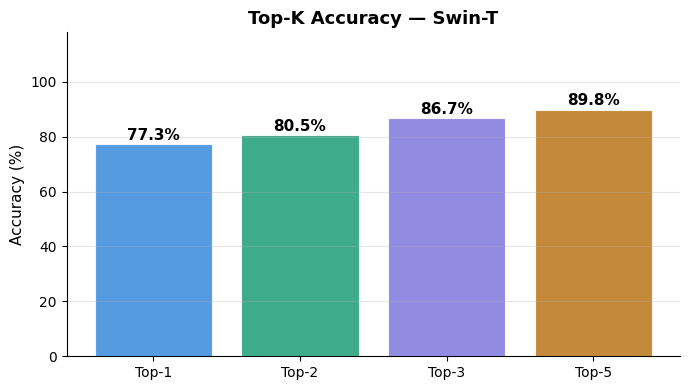

  ✓ Saved: eval_04_topk_accuracy.png

  SECTION 10 — PREDICTION CONFIDENCE


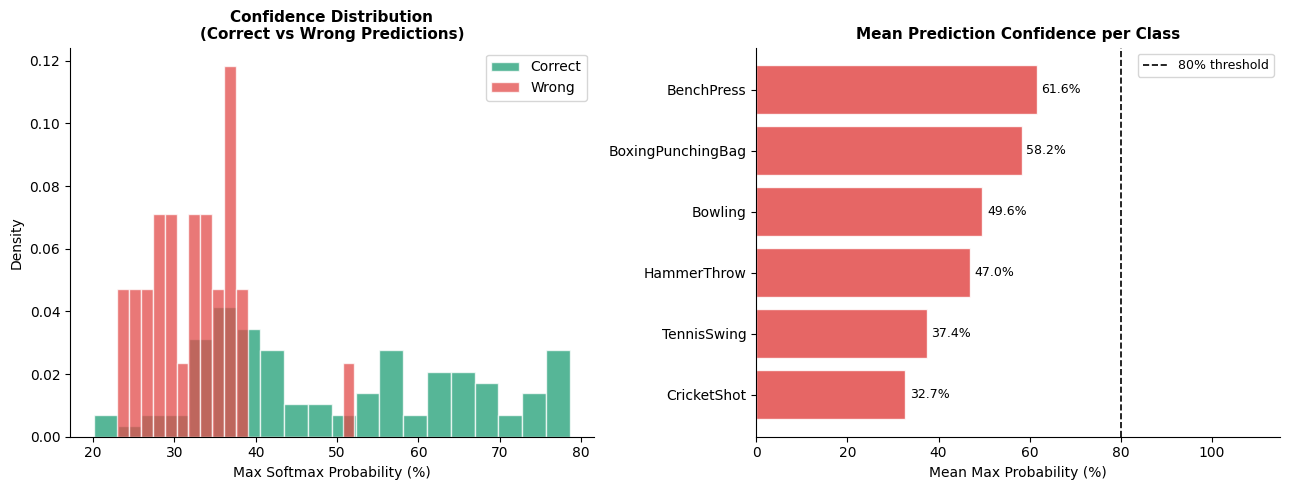

  ✓ Saved: eval_05_confidence.png

  SECTION 11 — PER-CLASS ACCURACY
            Class  Accuracy
       BenchPress   100.000
BoxingPunchingBag   100.000
      TennisSwing   100.000
      HammerThrow   100.000
          Bowling    59.375
      CricketShot    50.000


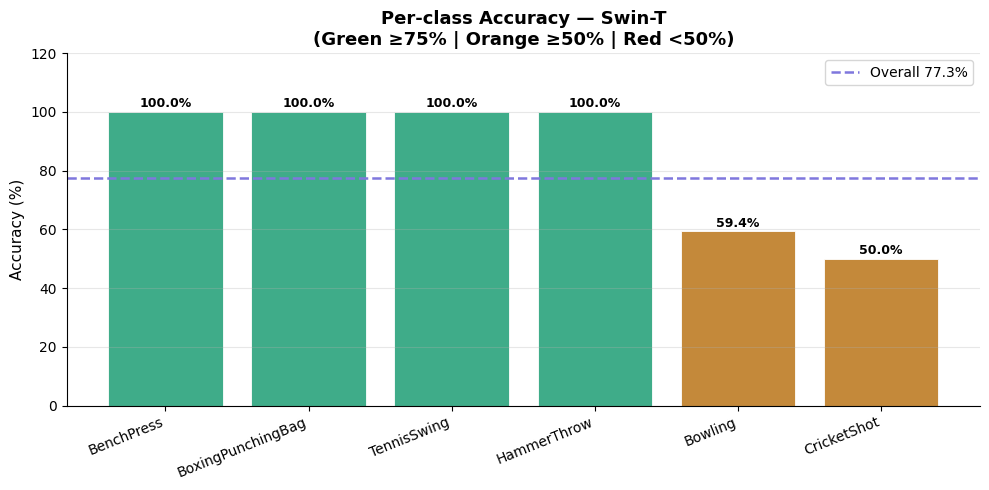

  ✓ Saved: eval_06_per_class_accuracy.png

  SECTION 12 — MISCLASSIFIED SAMPLES
  Total misclassified : 29


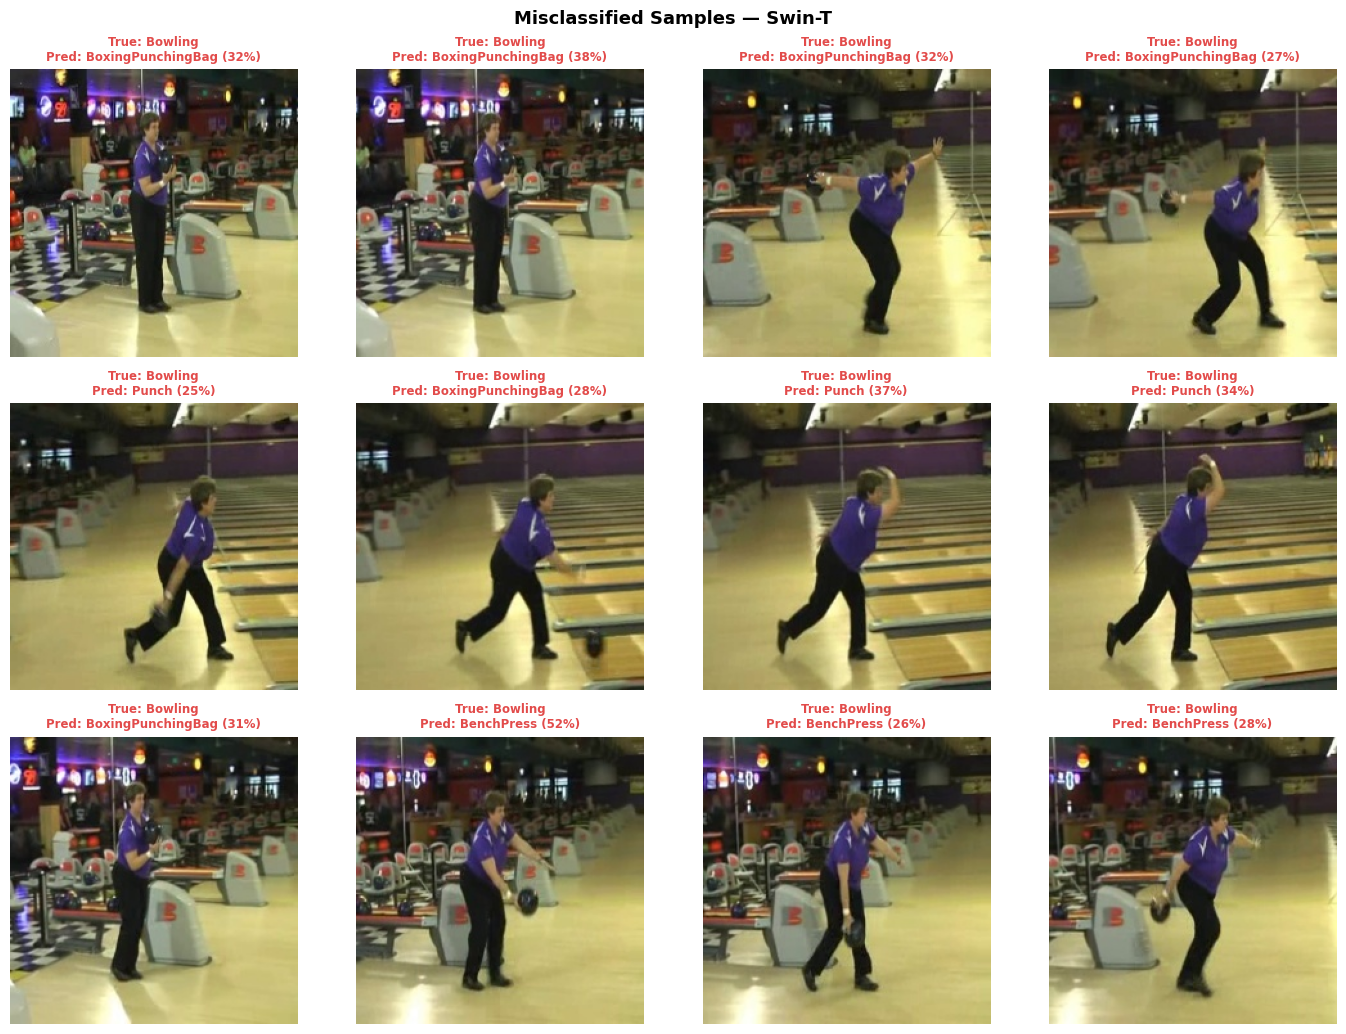

  ✓ Saved: eval_07_misclassified.png  (12 samples shown)

  SECTION 13 — CORRECTLY CLASSIFIED SAMPLES


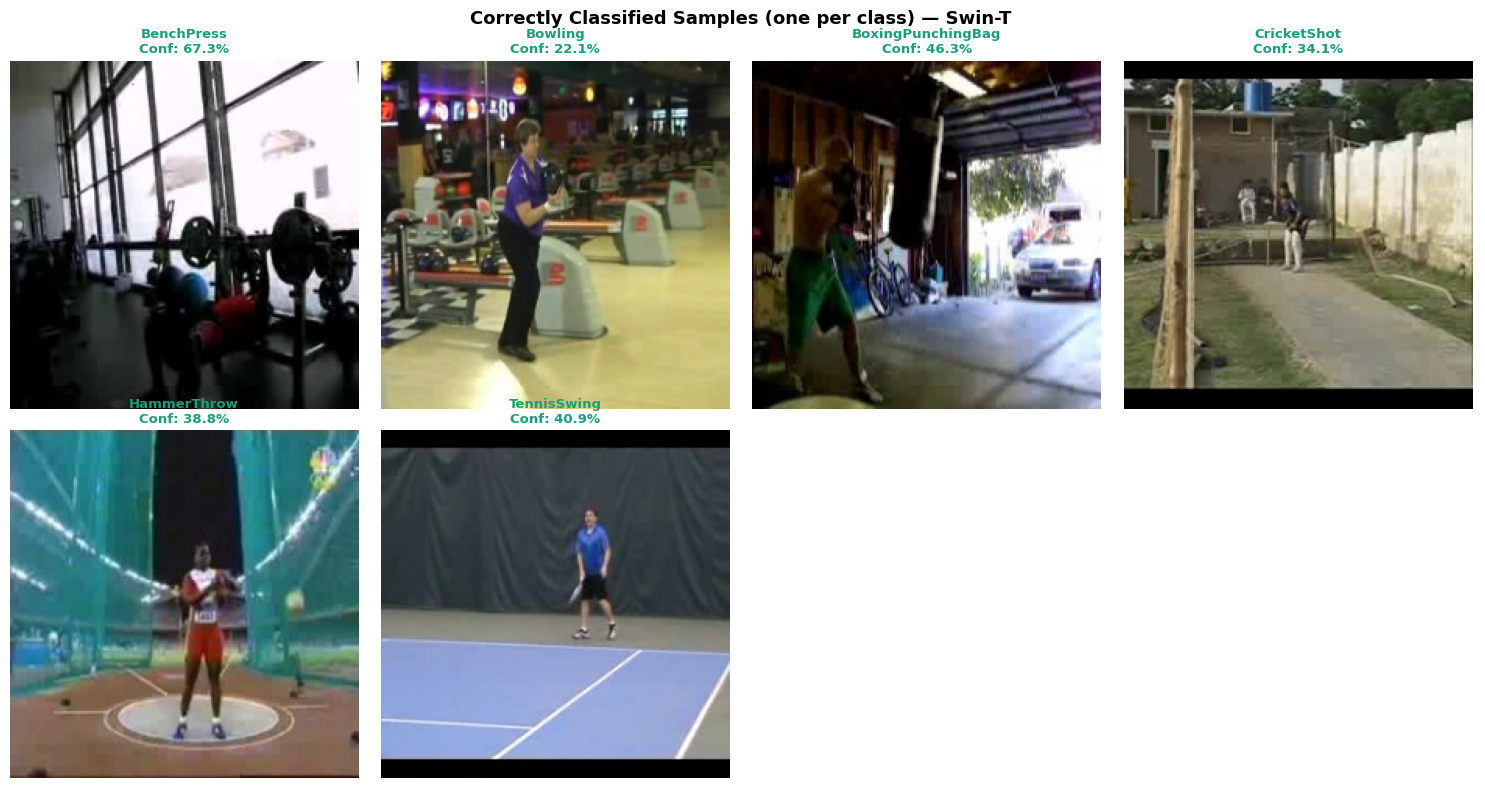

  ✓ Saved: eval_08_correct_samples.png

  SECTION 14 — FINAL SUMMARY
              Metric  Value
            Accuracy 77.34%
Precision (weighted) 0.8797
   Recall (weighted) 0.7734
 F1 Score (weighted) 0.7781
      Top-2 Accuracy 80.47%
      Top-3 Accuracy 86.72%
      Top-5 Accuracy 89.84%
          Best Epoch      3
        Total Params 27.53M
    Trainable Params 27.53M

  ALL OUTPUTS SAVED TO: /content/drive/MyDrive/MLMiniProject/SwinT
  ✓ eda_01_class_distribution.png
  ✓ eda_02_sample_frames.png
  ✓ eda_03_preprocessing_variants.png
  ✓ eda_04_pixel_intensity.png
  ✓ eda_05_mean_frames.png
  ✓ eda_06_brightness_boxplot.png
  ✓ eda_07_split_pie.png
  ✓ eda_08_frames_per_video.png
  ✓ training_01_curves.png
  ✓ training_02_gap.png
  ✓ eval_01_confusion_matrix.png
  ✓ eval_02_confusion_matrix_norm.png
  ✓ eval_03_per_class_metrics.png
  ✓ eval_04_topk_accuracy.png
  ✓ eval_05_confidence.png
  ✓ eval_06_per_class_accuracy.png
  ✓ eval_07_misclassified.png
  ✓ eval_08_correct_samples

In [ ]:
# ================================================================
#  SECTION 8 — CLASSIFICATION REPORT
#  (matches Section 5.2 of the outputs doc)
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 8 — CLASSIFICATION REPORT")
print("=" * 60)

# PRINT REPORT
print(classification_report(
    all_labels,
    all_preds,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    zero_division=0
))

# DICT REPORT
report = classification_report(
    all_labels,
    all_preds,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df  = (pd.DataFrame(report).T
                .iloc[:NUM_CLASSES]
                [["precision", "recall", "f1-score", "support"]])
report_df["support"] = report_df["support"].astype(int)

# grouped bar chart
x     = np.arange(NUM_CLASSES)
width = 0.26
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width,  report_df["precision"], width,
            label="Precision", color="#378ADD",  alpha=0.85)
b2 = ax.bar(x,          report_df["recall"],    width,
            label="Recall",    color="#1D9E75",  alpha=0.85)
b3 = ax.bar(x + width,  report_df["f1-score"],  width,
            label="F1 Score",  color="#7F77DD",  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right", fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Per-class Precision / Recall / F1 — Swin-T",
             fontsize=13, fontweight="bold")
ax.axhline(acc_swin, color="#E24B4A", linestyle="--", linewidth=1.5,
           label=f"Overall Acc {acc_swin*100:.1f}%")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

# annotate F1 bars
for bar in b3:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.2f}",
            ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eval_03_per_class_metrics.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: eval_03_per_class_metrics.png")


# ================================================================
#  SECTION 9 — TOP-K ACCURACY
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 9 — TOP-K ACCURACY")
print("=" * 60)

def topk_accuracy(probs, labels, k):
    topk = np.argsort(probs, axis=1)[:, -k:]
    return np.mean([labels[i] in topk[i] for i in range(len(labels))])

labels_arr = np.array(all_labels)
top1 = topk_accuracy(all_probs, labels_arr, 1)
top2 = topk_accuracy(all_probs, labels_arr, 2)
top3 = topk_accuracy(all_probs, labels_arr, 3)
top5 = topk_accuracy(all_probs, labels_arr, 5)

print(f"\n  Top-1 Accuracy : {top1*100:.2f}%")
print(f"  Top-2 Accuracy : {top2*100:.2f}%")
print(f"  Top-3 Accuracy : {top3*100:.2f}%")
print(f"  Top-5 Accuracy : {top5*100:.2f}%")

ks   = [1, 2, 3, 5]
accs = [top1, top2, top3, top5]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f"Top-{k}" for k in ks],
              [a * 100 for a in accs],
              color=["#378ADD", "#1D9E75", "#7F77DD", "#BA7517"],
              alpha=0.85, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val*100:.1f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
ax.set_ylim(0, 118)
ax.set_title("Top-K Accuracy — Swin-T",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eval_04_topk_accuracy.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("   Saved: eval_04_topk_accuracy.png")


# ================================================================
#  SECTION 10 — PREDICTION CONFIDENCE DISTRIBUTION
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 10 — PREDICTION CONFIDENCE")
print("=" * 60)

max_probs  = all_probs.max(axis=1)
is_correct = (np.array(all_preds) == labels_arr).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# overall confidence histogram
axes[0].hist(max_probs[is_correct == 1] * 100, bins=20,
             alpha=0.75, color="#1D9E75",  label="Correct",
             density=True, edgecolor="white")
axes[0].hist(max_probs[is_correct == 0] * 100, bins=20,
             alpha=0.75, color="#E24B4A", label="Wrong",
             density=True, edgecolor="white")
axes[0].set_title("Confidence Distribution\n(Correct vs Wrong Predictions)",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Max Softmax Probability (%)", fontsize=10)
axes[0].set_ylabel("Density", fontsize=10)
axes[0].legend(fontsize=10)

# per-class mean confidence
class_conf = {}
for c_idx, cls in enumerate(CLASS_NAMES):
    mask = labels_arr == c_idx
    if mask.sum() > 0:
        class_conf[cls] = max_probs[mask].mean() * 100

conf_df = (pd.DataFrame({"Class": list(class_conf.keys()),
                          "Confidence": list(class_conf.values())})
             .sort_values("Confidence", ascending=True))
colors_conf = ["#E24B4A" if c < 70 else "#1D9E75"
               for c in conf_df["Confidence"]]
axes[1].barh(conf_df["Class"], conf_df["Confidence"],
             color=colors_conf, alpha=0.85, edgecolor="white")
axes[1].axvline(80, color="black", linestyle="--",
                linewidth=1.2, label="80% threshold")
axes[1].set_title("Mean Prediction Confidence per Class",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Mean Max Probability (%)", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 115)
for i, (_, row) in enumerate(conf_df.iterrows()):
    axes[1].text(row["Confidence"] + 1, i,
                 f"{row['Confidence']:.1f}%",
                 va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eval_05_confidence.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("   Saved: eval_05_confidence.png")


# ================================================================
#  SECTION 11 — PER-CLASS ACCURACY BAR
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 11 — PER-CLASS ACCURACY")
print("=" * 60)

per_class_acc = {}
for c_idx, cls in enumerate(CLASS_NAMES):
    mask = labels_arr == c_idx
    if mask.sum() > 0:
        per_class_acc[cls] = (
            np.array(all_preds)[mask] == labels_arr[mask]
        ).mean() * 100

acc_df = (pd.DataFrame({"Class": list(per_class_acc.keys()),
                         "Accuracy": list(per_class_acc.values())})
            .sort_values("Accuracy", ascending=False)
            .reset_index(drop=True))
print(acc_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#1D9E75" if v >= 75 else
              "#BA7517" if v >= 50 else
              "#E24B4A" for v in acc_df["Accuracy"]]
bars = ax.bar(acc_df["Class"], acc_df["Accuracy"],
              color=bar_colors, alpha=0.85,
              edgecolor="white", linewidth=0.7)
ax.axhline(acc_swin * 100, color="#7F77DD",
           linestyle="--", linewidth=1.8,
           label=f"Overall {acc_swin*100:.1f}%")
for bar, val in zip(bars, acc_df["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_ylim(0, 120)
ax.set_title("Per-class Accuracy — Swin-T\n"
             "(Green ≥75% | Orange ≥50% | Red <50%)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=22, ha="right", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eval_06_per_class_accuracy.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("   Saved: eval_06_per_class_accuracy.png")


# ================================================================
#  SECTION 12 — MISCLASSIFIED SAMPLES VISUAL GRID
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 12 — MISCLASSIFIED SAMPLES")
print("=" * 60)

# collect mis-classified frame paths from test set
misclassified = []
for idx, (pred, true) in enumerate(zip(all_preds, all_labels)):
    if pred != true:
        path = test_full.samples[test_idx[idx]][0]
        misclassified.append({
            "path":     path,
            "true":     CLASS_NAMES[true],
            "pred":     CLASS_NAMES[pred],
            "conf":     all_probs[idx][pred] * 100
        })

print(f"  Total misclassified : {len(misclassified)}")

# show up to 12
show_n = min(12, len(misclassified))
ncols  = 4
nrows  = (show_n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes = axes.flatten()

for i in range(show_n):
    sample = misclassified[i]
    img    = cv2.cvtColor(cv2.imread(sample["path"]),
                          cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {sample['true']}\nPred: {sample['pred']} ({sample['conf']:.0f}%)",
        fontsize=8.5, color="#E24B4A", fontweight="bold"
    )
    axes[i].axis("off")

# hide unused axes
for j in range(show_n, len(axes)):
    axes[j].axis("off")

fig.suptitle("Misclassified Samples — Swin-T",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eval_07_misclassified.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: eval_07_misclassified.png  ({show_n} samples shown)")


# ================================================================
#  SECTION 13 — CORRECTLY CLASSIFIED SAMPLES VISUAL GRID
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 13 — CORRECTLY CLASSIFIED SAMPLES")
print("=" * 60)

# 1 high-confidence correct sample per class
correct_samples = {}
for idx, (pred, true) in enumerate(zip(all_preds, all_labels)):
    cls = CLASS_NAMES[true]
    if pred == true and cls not in correct_samples:
        path = test_full.samples[test_idx[idx]][0]
        correct_samples[cls] = {
            "path": path,
            "conf": all_probs[idx][pred] * 100
        }

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()
for i, cls in enumerate(sorted(correct_samples.keys())):
    s   = correct_samples[cls]
    img = cv2.cvtColor(cv2.imread(s["path"]),
                       cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(
        f"{cls}\nConf: {s['conf']:.1f}%",
        fontsize=9.5, color="#1D9E75", fontweight="bold"
    )
    axes[i].axis("off")

# hide unused
for j in range(len(correct_samples), len(axes)):
    axes[j].axis("off")

fig.suptitle("Correctly Classified Samples (one per class) — Swin-T",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "eval_08_correct_samples.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("   Saved: eval_08_correct_samples.png")


# ================================================================
#  SECTION 14 — FINAL SUMMARY
# ================================================================
print("\n" + "=" * 60)
print("  SECTION 14 — FINAL SUMMARY")
print("=" * 60)

summary_df = pd.DataFrame({
    "Metric":      ["Accuracy", "Precision (weighted)",
                    "Recall (weighted)", "F1 Score (weighted)",
                    "Top-2 Accuracy",   "Top-3 Accuracy",
                    "Top-5 Accuracy",   "Best Epoch",
                    "Total Params",     "Trainable Params"],
    "Value":       [f"{acc_swin*100:.2f}%",
                    f"{prec_swin:.4f}",
                    f"{rec_swin:.4f}",
                    f"{f1_swin:.4f}",
                    f"{top2*100:.2f}%",
                    f"{top3*100:.2f}%",
                    f"{top5*100:.2f}%",
                    str(history["val_acc"].index(max(history["val_acc"])) + 1),
                    f"{total_p:.2f}M",
                    f"{trainable_p:.2f}M"],
})
print(summary_df.to_string(index=False))

print("\n" + "=" * 60)
print("  ALL OUTPUTS SAVED TO:", SAVE_DIR)
print("=" * 60)

all_saved = [
    "eda_01_class_distribution.png",
    "eda_02_sample_frames.png",
    "eda_03_preprocessing_variants.png",
    "eda_04_pixel_intensity.png",
    "eda_05_mean_frames.png",
    "eda_06_brightness_boxplot.png",
    "eda_07_split_pie.png",
    "eda_08_frames_per_video.png",
    "training_01_curves.png",
    "training_02_gap.png",
    "eval_01_confusion_matrix.png",
    "eval_02_confusion_matrix_norm.png",
    "eval_03_per_class_metrics.png",
    "eval_04_topk_accuracy.png",
    "eval_05_confidence.png",
    "eval_06_per_class_accuracy.png",
    "eval_07_misclassified.png",
    "eval_08_correct_samples.png",
    "metrics.json",
    "swint_best.pth",
]
for f in all_saved:
    print(f"  {f}")